# Minería de Datos - 2026

### Universidad del Valle de Guatemala  
### Facultad de Ingeniería  
### Departamento de Ciencias de la Computación  
### CC3074 – Minería de Datos  
### Semestre I – 2026  

---

## Predicción de Precios de Viviendas - InmoValor S.A.

### Integrantes
- **Vianka Vanessa Castro Ordoñez** - 23201  
- **Ricardo Arturo Godínez Sánchez** - 23247  
- **Jorge Felipe Aguilar Portillo** - 23198  


## Contexto del Proyecto

InmoValor S.A. es una empresa innovadora del sector inmobiliario que ha decidido fortalecer su proceso de valoración de propiedades mediante el uso de herramientas de analítica de datos y modelos predictivos. En un mercado inmobiliario dinámico, donde el precio de una vivienda puede variar significativamente según factores como la ubicación, el tamaño, la calidad de construcción, el estado general del inmueble y otras características específicas, resulta fundamental contar con metodologías objetivas y precisas para estimar el valor real de las propiedades.

Con el objetivo de mejorar sus procesos de evaluación, la empresa ha incorporado un equipo de analistas de datos encargado de estudiar el conjunto de datos **House Prices: Advanced Regression Techniques**, disponible en Kaggle. Este dataset contiene información detallada sobre distintas viviendas y sus atributos, lo que permite explorar relaciones entre variables y construir modelos de regresión capaces de predecir el precio de venta de una casa.



## Introducción

La predicción de precios de viviendas representa uno de los problemas más importantes dentro del análisis de datos aplicado al sector inmobiliario. Estimar correctamente el valor de una propiedad no solo beneficia a empresas dedicadas a la compra, venta o financiamiento de inmuebles, sino que también aporta objetividad y respaldo cuantitativo a la toma de decisiones estratégicas.

En este proyecto se trabajará con el dataset **House Prices: Advanced Regression Techniques**, el cual contiene múltiples variables descriptivas de viviendas, incluyendo características físicas, de calidad y ubicación. A partir de este conjunto de datos, se desarrollará un análisis integral que permitirá comprender mejor el comportamiento de las variables, identificar patrones relevantes y construir modelos de regresión lineal orientados a predecir el precio de venta de las propiedades.

## Objetivo General

Desarrollar y evaluar modelos de regresión lineal que permitan predecir de manera precisa el precio de las viviendas utilizando el conjunto de datos **House Prices: Advanced Regression Techniques**, con el fin de apoyar el proceso de valoración inmobiliaria de InmoValor S.A.

## Objetivos Específicos

- Realizar un análisis exploratorio de datos para comprender la estructura del dataset e identificar variables relevantes para la predicción del precio.
- Aplicar técnicas de preprocesamiento para tratar valores faltantes, transformar variables y preparar los datos para el modelado.
- Analizar agrupamientos dentro de los datos para identificar perfiles o grupos de viviendas con características similares.
- Construir un modelo de regresión lineal univariado utilizando una variable predictora relevante.
- Construir un modelo de regresión lineal múltiple con variables numéricas y analizar su desempeño.
- Evaluar la presencia de multicolinealidad y sobreajuste en los modelos generados.
- Comparar el desempeño de los distintos modelos con base en métricas de error y capacidad predictiva.
- Seleccionar el modelo más adecuado para estimar el precio de las viviendas.



## 1. Descarga y Carga de Datos

**Requisito 1:** Descargar y cargar los conjuntos de datos desde Kaggle (House Prices: Advanced Regression Techniques).

**Fijación de Reproducibilidad:** Para garantizar que todos los resultados sean reproducibles, se fijarán las semillas aleatorias en todos los procesos que involucren aleatoriedad (división de datos, clustering, etc.).

Importamos las librerías necesarias para el análisis de datos, visualización y modelado.

In [2]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Todas las operaciones aleatorias usarán estas semillas para garantizar
# que los resultados sean exactamente los mismos en cada ejecución
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Librerías para preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Librerías para clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Librerías para división de datos
from sklearn.model_selection import train_test_split

# Librerías para modelado de regresión
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import scipy.stats as stats

# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("CONFIGURACIÓN INICIAL")
print("="*80)
print(f" Semilla aleatoria fijada: {RANDOM_STATE}")
print(" Librerías importadas correctamente")
print(" Todas las operaciones serán reproducibles")
print("="*80)

CONFIGURACIÓN INICIAL
 Semilla aleatoria fijada: 42
 Librerías importadas correctamente
 Todas las operaciones serán reproducibles


### 1.1 Carga e Inspección Inicial de Datos

Cargamos el dataset de entrenamiento proporcionado por Kaggle y realizamos una inspección inicial para entender la estructura de los datos.

In [3]:
# Cargar el dataset de entrenamiento
df = pd.read_csv('train.csv')

print("="*80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*80)
print(f"\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nMemoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

INFORMACIÓN GENERAL DEL DATASET

Dimensiones del dataset: 1460 filas x 81 columnas

Memoria utilizada: 3.43 MB


## Primeras 5 filas del dataset:

In [4]:
# Visualizar las primeras filas del dataset
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Información General del Dataset en Columnas

In [5]:
# Información detallada de las columnas
print("\nInformación de las columnas:")
df.info()


Información de las columnas:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   in

# Estadística Descriptiva de variables numéricas 

In [6]:
# Estadísticas descriptivas de variables numéricas
print("\nEstadísticas descriptivas de variables numéricas:")
df.describe()


Estadísticas descriptivas de variables numéricas:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 1.2 Identificación de Tipos de Variables

Es fundamental clasificar las variables según su tipo para aplicar el preprocesamiento adecuado.

In [7]:
# Identificar variables numéricas y categóricas
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("="*80)
print("CLASIFICACIÓN DE VARIABLES")
print("="*80)
print(f"\nVariables Numéricas ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nVariables Categóricas ({len(categorical_cols)}):")
print(categorical_cols)

# Variable objetivo
target = 'SalePrice'
print(f"\n*** Variable Objetivo: {target} ***")

CLASIFICACIÓN DE VARIABLES

Variables Numéricas (38):
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables Categóricas (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrica

## 2. Análisis Exploratorio Extenso de Datos (EDA)

Realizaremos un análisis exploratorio exhaustivo de los datos, explicando todos los hallazgos y llegando a conclusiones interesantes para predecir. Incluye explicación del preprocesamiento necesario.



### 2.1 Análisis de Valores Faltantes

Los valores faltantes pueden afectar significativamente el desempeño de nuestro modelo. Identificaremos qué variables tienen datos faltantes y en qué proporción.

In [8]:
# Calcular porcentaje de valores faltantes por columna
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df)) * 100
})

# Filtrar solo columnas con valores faltantes
missing_data = missing_data[missing_data['Valores_Faltantes'] > 0].sort_values(
    'Porcentaje', ascending=False
).reset_index(drop=True)

print("="*80)
print("ANÁLISIS DE VALORES FALTANTES")
print("="*80)
print(f"\nColumnas con valores faltantes: {len(missing_data)}")
print("\nTop 20 columnas con más valores faltantes:\n")
print(missing_data.head(20))

ANÁLISIS DE VALORES FALTANTES

Columnas con valores faltantes: 19

Top 20 columnas con más valores faltantes:

         Columna  Valores_Faltantes  Porcentaje
0         PoolQC               1453   99.520548
1    MiscFeature               1406   96.301370
2          Alley               1369   93.767123
3          Fence               1179   80.753425
4     MasVnrType                872   59.726027
5    FireplaceQu                690   47.260274
6    LotFrontage                259   17.739726
7     GarageType                 81    5.547945
8    GarageYrBlt                 81    5.547945
9   GarageFinish                 81    5.547945
10    GarageQual                 81    5.547945
11    GarageCond                 81    5.547945
12  BsmtExposure                 38    2.602740
13  BsmtFinType2                 38    2.602740
14      BsmtQual                 37    2.534247
15      BsmtCond                 37    2.534247
16  BsmtFinType1                 37    2.534247
17    MasVnrArea         

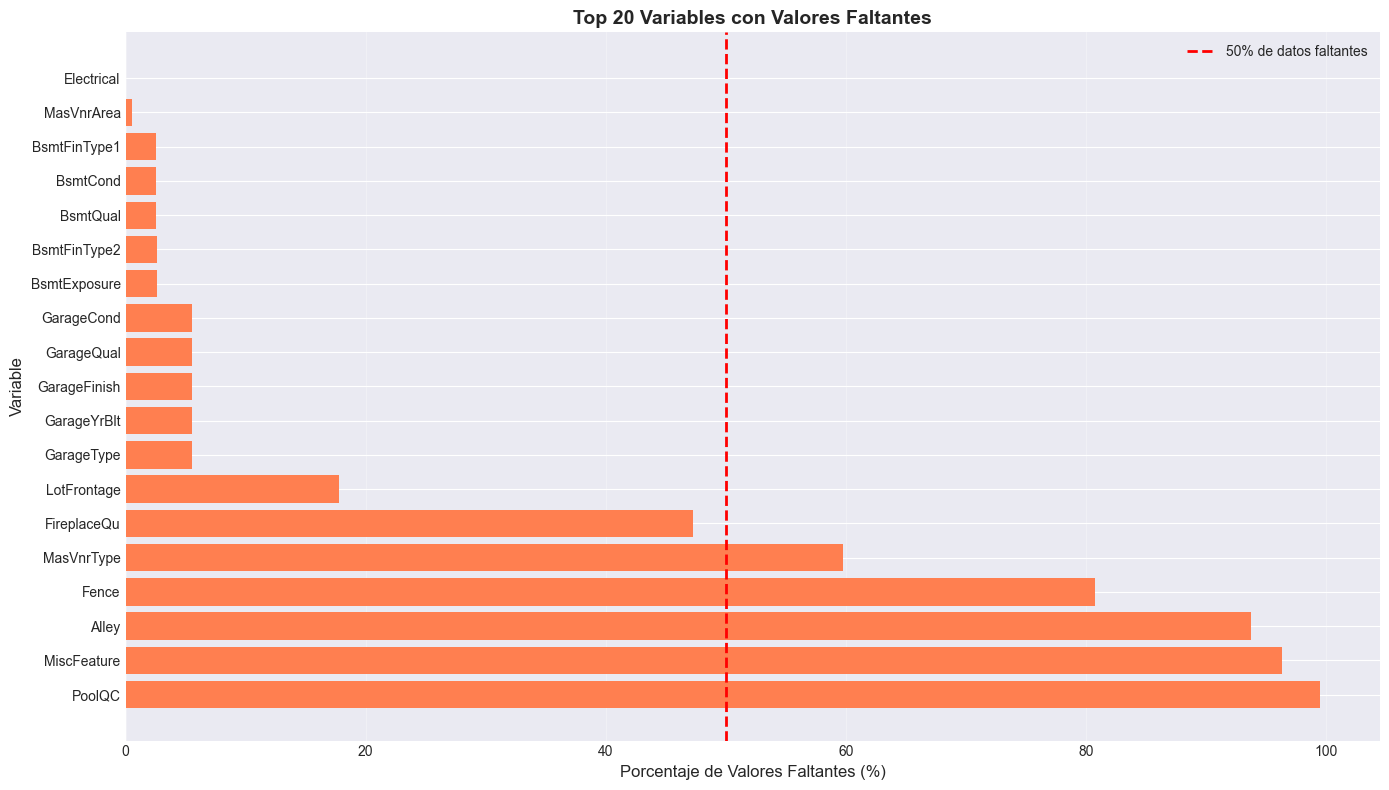


 HALLAZGOS:
- Variables con >50% de datos faltantes podrían no ser útiles para el modelo
- Necesitaremos aplicar técnicas de imputación o eliminar estas columnas


In [9]:
# Visualización de valores faltantes
if len(missing_data) > 0:
    plt.figure(figsize=(14, 8))
    
    # Mostrar las top 20 variables con más valores faltantes
    top_missing = missing_data.head(20)
    
    plt.barh(top_missing['Columna'], top_missing['Porcentaje'], color='coral')
    plt.xlabel('Porcentaje de Valores Faltantes (%)', fontsize=12)
    plt.ylabel('Variable', fontsize=12)
    plt.title('Top 20 Variables con Valores Faltantes', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # Línea de referencia en 50%
    plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% de datos faltantes')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n HALLAZGOS:")
    print("- Variables con >50% de datos faltantes podrían no ser útiles para el modelo")
    print("- Necesitaremos aplicar técnicas de imputación o eliminar estas columnas")

Podemos notar que Pool Quality, Características Miscelaneas, Tipo de Alley (entrada), Calidad de Fensa, Revestimiento de Paredes, Calidad de Hoguera no nos brindan mucha información ya que la gran parte de los hogares no tienen. Por lo que no serán de mucha utilidad para nuestro modelo y vamos a quitar. 

### 2.2 Análisis de la Variable Objetivo (SalePrice)

Analizar la distribución del precio de venta es crucial para entender el mercado inmobiliario y detectar posibles transformaciones necesarias.

In [10]:
# Estadísticas del precio de venta
print("="*80)
print("ANÁLISIS DE VARIABLE OBJETIVO: SALEPRICE")
print("="*80)
print(f"\nMedia: ${df['SalePrice'].mean():,.2f}")
print(f"Mediana: ${df['SalePrice'].median():,.2f}")
print(f"Desviación Estándar: ${df['SalePrice'].std():,.2f}")
print(f"Mínimo: ${df['SalePrice'].min():,.2f}")
print(f"Máximo: ${df['SalePrice'].max():,.2f}")
print(f"\nRango intercuartílico (IQR):")
print(f"Q1 (25%): ${df['SalePrice'].quantile(0.25):,.2f}")
print(f"Q3 (75%): ${df['SalePrice'].quantile(0.75):,.2f}")

ANÁLISIS DE VARIABLE OBJETIVO: SALEPRICE

Media: $180,921.20
Mediana: $163,000.00
Desviación Estándar: $79,442.50
Mínimo: $34,900.00
Máximo: $755,000.00

Rango intercuartílico (IQR):
Q1 (25%): $129,975.00
Q3 (75%): $214,000.00


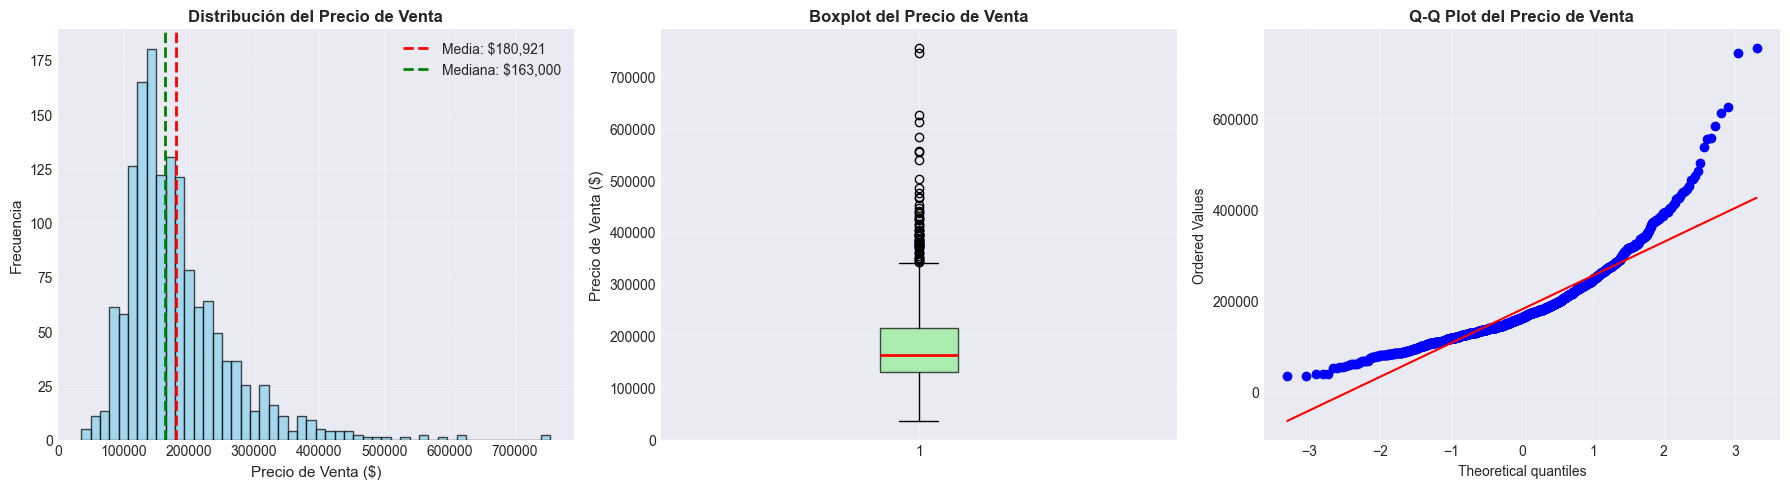


 HALLAZGOS:
- Asimetría (Skewness): 1.883
  → La distribución está sesgada a la derecha (cola larga hacia valores altos)
  → Esto es común en precios de viviendas donde existen propiedades de lujo

- Curtosis (Kurtosis): 6.536
  → La distribución tiene colas más pesadas que una distribución normal

- La distribución NO es normal → Considerar transformación logarítmica para el modelado


In [11]:
# Visualización de la distribución del precio
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(df['SalePrice'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Precio de Venta ($)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución del Precio de Venta', fontsize=12, fontweight='bold')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${df["SalePrice"].median():,.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(df['SalePrice'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Precio de Venta ($)', fontsize=11)
axes[1].set_title('Boxplot del Precio de Venta', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# QQ-plot para evaluar normalidad
from scipy import stats
stats.probplot(df['SalePrice'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot del Precio de Venta', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular skewness y kurtosis
skewness = df['SalePrice'].skew()
kurtosis = df['SalePrice'].kurtosis()

print("\n HALLAZGOS:")
print(f"- Asimetría (Skewness): {skewness:.3f}")
if skewness > 0.5:
    print("  → La distribución está sesgada a la derecha (cola larga hacia valores altos)")
    print("  → Esto es común en precios de viviendas donde existen propiedades de lujo")
print(f"\n- Curtosis (Kurtosis): {kurtosis:.3f}")
if kurtosis > 0:
    print("  → La distribución tiene colas más pesadas que una distribución normal")
print("\n- La distribución NO es normal → Considerar transformación logarítmica para el modelado")

### 2.3 Análisis de Correlación

Identificaremos las variables numéricas que tienen mayor correlación con el precio de venta.

In [12]:
# Calcular matriz de correlación
correlation_matrix = df[numerical_cols].corr()

# Obtener correlaciones con SalePrice
price_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)

print("="*80)
print("TOP 15 VARIABLES MÁS CORRELACIONADAS CON SALEPRICE")
print("="*80)
print("\nCorrelaciones positivas más fuertes:")
print(price_corr.head(15))

TOP 15 VARIABLES MÁS CORRELACIONADAS CON SALEPRICE

Correlaciones positivas más fuertes:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


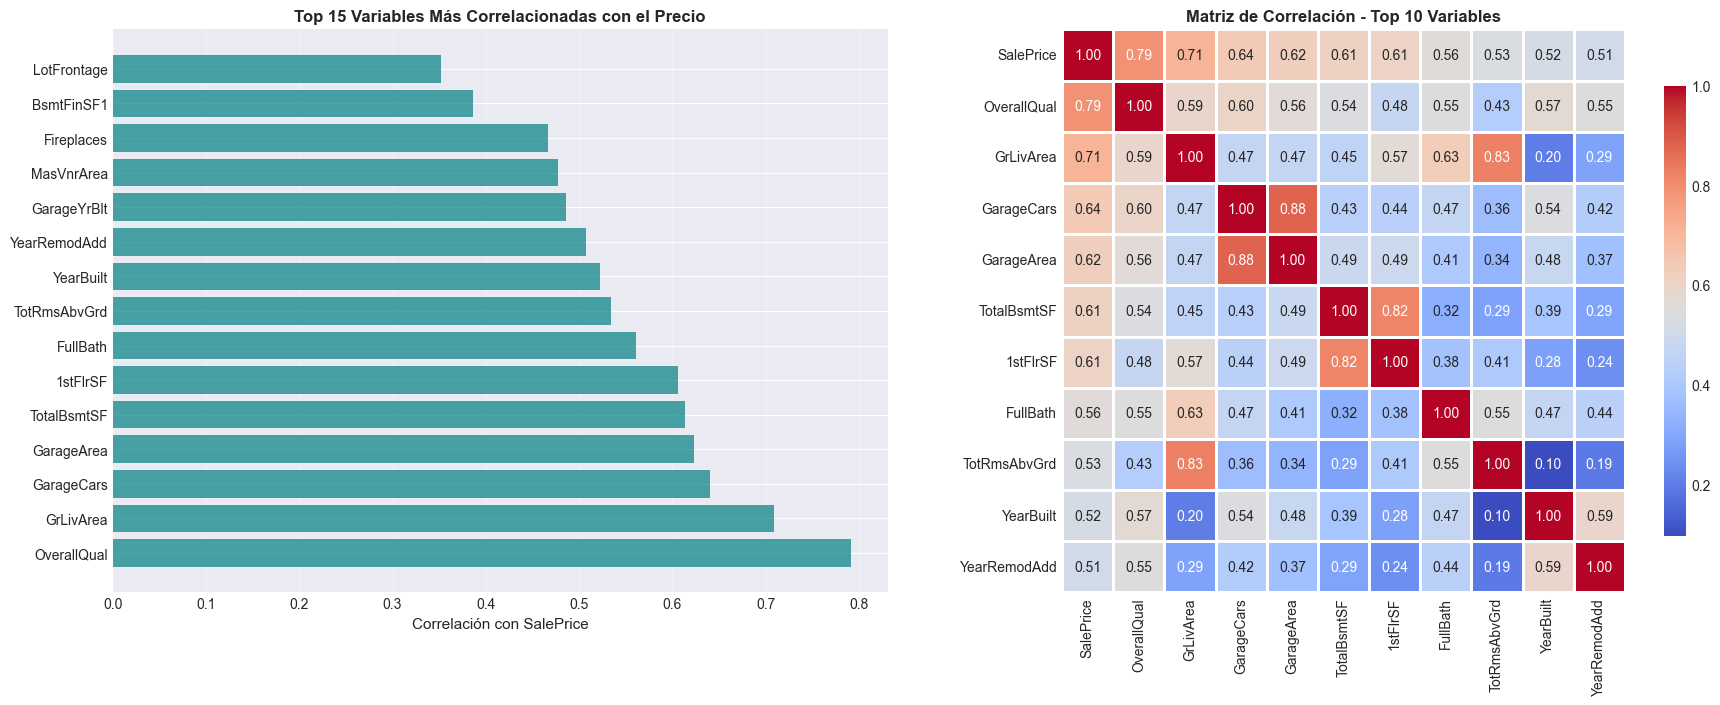

In [13]:
# Visualización de correlaciones con SalePrice
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de barras con top correlaciones
top_corr = price_corr.head(16)[1:]  # Excluir SalePrice consigo mismo
axes[0].barh(range(len(top_corr)), top_corr.values, color='teal', alpha=0.7)
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr.index)
axes[0].set_xlabel('Correlación con SalePrice', fontsize=11)
axes[0].set_title('Top 15 Variables Más Correlacionadas con el Precio', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Heatmap de las variables más correlacionadas
top_vars = price_corr.head(11).index.tolist()  # Top 10 + SalePrice
top_corr_matrix = df[top_vars].corr()

sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Matriz de Correlación - Top 10 Variables', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()



## HALLAZGOS:

- Las variables con mayor correlación positiva con el precio de venta son OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, FullBath, TotRmsAbvGrd, YearBuilt y YearRemodAdd.
- La variable con mayor correlación negativa con el precio de venta es KitchenAbvGr.
- La mayoría de las variables numéricas presentan una distribución sesgada, lo que sugiere la necesidad de aplicar transformaciones para mejorar la normalidad de los datos.

### 2.4 Análisis de Variables Clave

Profundizaremos en las variables más importantes identificadas en el análisis de correlación.

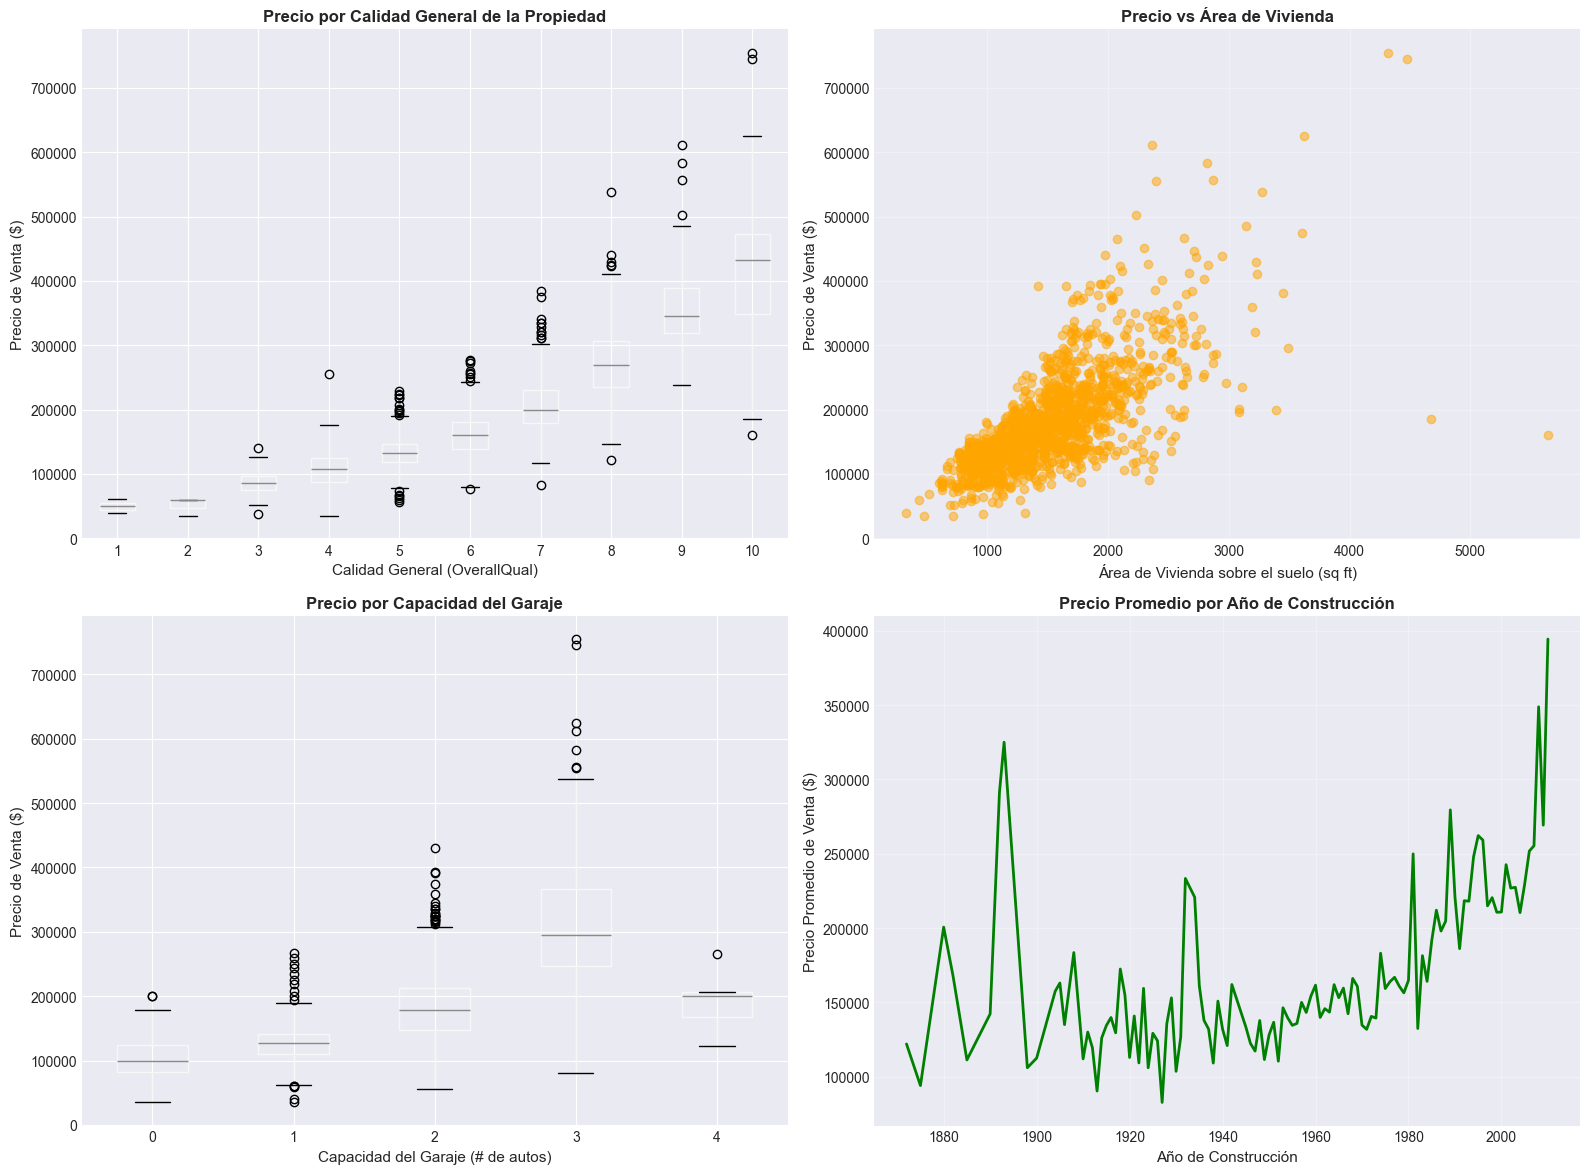


 HALLAZGOS:
- Relación clara entre calidad y precio: a mayor calidad, mayor precio
- El área de vivienda tiene una relación positiva con el precio (aunque con algunos outliers)
- Propiedades con mayor capacidad de garaje tienden a ser más costosas
- Las viviendas más recientes generalmente tienen precios más altos


In [14]:
# Análisis de OverallQual vs SalePrice
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. OverallQual vs SalePrice
df.boxplot(column='SalePrice', by='OverallQual', ax=axes[0, 0])
axes[0, 0].set_xlabel('Calidad General (OverallQual)', fontsize=11)
axes[0, 0].set_ylabel('Precio de Venta ($)', fontsize=11)
axes[0, 0].set_title('Precio por Calidad General de la Propiedad', fontsize=12, fontweight='bold')
axes[0, 0].get_figure().suptitle('')  # Eliminar título automático

# 2. GrLivArea vs SalePrice
axes[0, 1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='orange')
axes[0, 1].set_xlabel('Área de Vivienda sobre el suelo (sq ft)', fontsize=11)
axes[0, 1].set_ylabel('Precio de Venta ($)', fontsize=11)
axes[0, 1].set_title('Precio vs Área de Vivienda', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. GarageCars vs SalePrice
df.boxplot(column='SalePrice', by='GarageCars', ax=axes[1, 0])
axes[1, 0].set_xlabel('Capacidad del Garaje (# de autos)', fontsize=11)
axes[1, 0].set_ylabel('Precio de Venta ($)', fontsize=11)
axes[1, 0].set_title('Precio por Capacidad del Garaje', fontsize=12, fontweight='bold')
axes[1, 0].get_figure().suptitle('')  # Eliminar título automático

# 4. YearBuilt vs SalePrice
year_price = df.groupby('YearBuilt')['SalePrice'].mean()
axes[1, 1].plot(year_price.index, year_price.values, color='green', linewidth=2)
axes[1, 1].set_xlabel('Año de Construcción', fontsize=11)
axes[1, 1].set_ylabel('Precio Promedio de Venta ($)', fontsize=11)
axes[1, 1].set_title('Precio Promedio por Año de Construcción', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n HALLAZGOS:")
print("- Relación clara entre calidad y precio: a mayor calidad, mayor precio")
print("- El área de vivienda tiene una relación positiva con el precio (aunque con algunos outliers)")
print("- Propiedades con mayor capacidad de garaje tienden a ser más costosas")
print("- Las viviendas más recientes generalmente tienen precios más altos")

### 2.5 Análisis de Variables Categóricas

Exploraremos las variables categóricas más relevantes para entender su impacto en el precio.

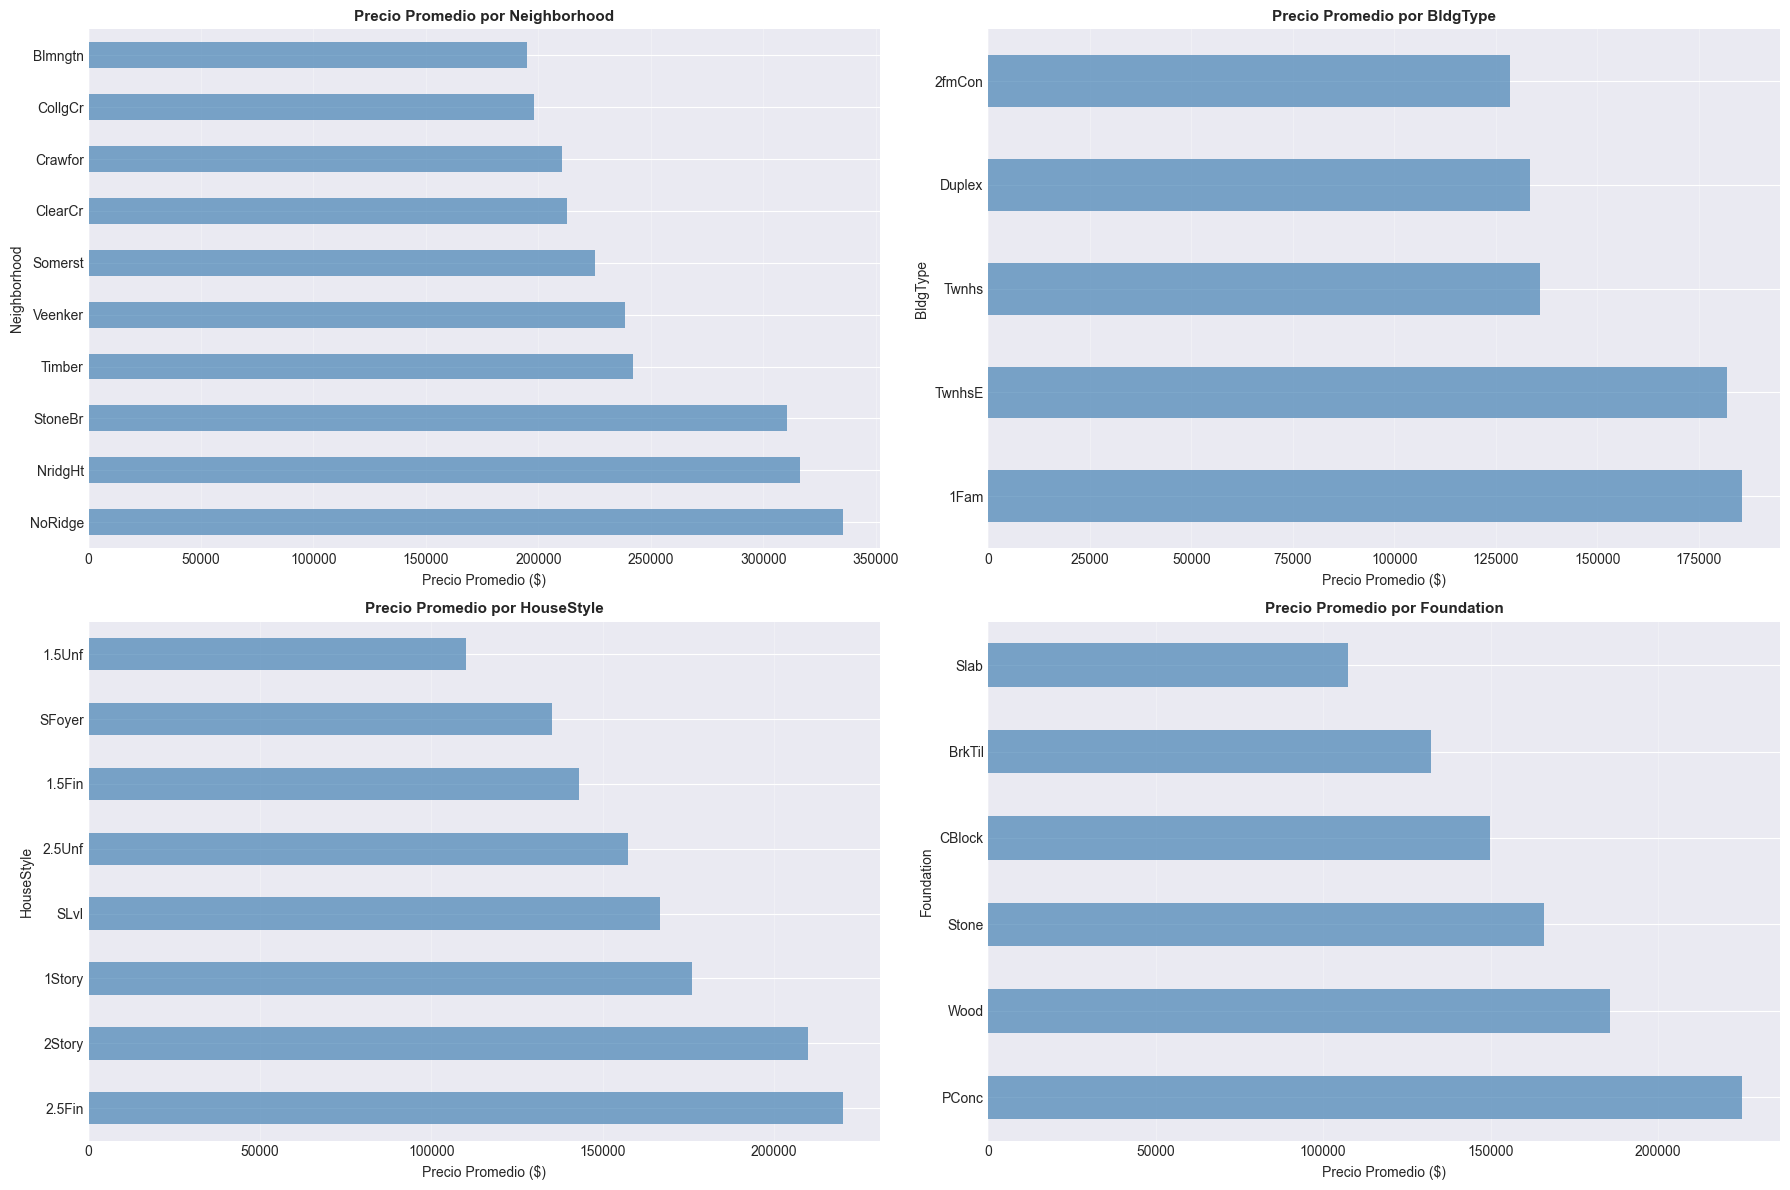


 HALLAZGOS:
- El vecindario (Neighborhood) es un factor determinante en el precio
- El tipo de edificación (BldgType) y estilo de casa influyen en la valoración
- El tipo de cimentación también puede afectar el precio de la propiedad


In [15]:
# Análisis de variables categóricas clave
categorical_key_vars = ['Neighborhood', 'BldgType', 'HouseStyle', 'Foundation']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for idx, var in enumerate(categorical_key_vars):
    if var in df.columns:
        # Calcular precio promedio por categoría
        avg_price = df.groupby(var)['SalePrice'].mean().sort_values(ascending=False)
        
        # Limitar a top 10 para mejor visualización
        if len(avg_price) > 10:
            avg_price = avg_price.head(10)
        
        avg_price.plot(kind='barh', ax=axes[idx], color='steelblue', alpha=0.7)
        axes[idx].set_xlabel('Precio Promedio ($)', fontsize=10)
        axes[idx].set_ylabel(var, fontsize=10)
        axes[idx].set_title(f'Precio Promedio por {var}', fontsize=11, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n HALLAZGOS:")
print("- El vecindario (Neighborhood) es un factor determinante en el precio")
print("- El tipo de edificación (BldgType) y estilo de casa influyen en la valoración")
print("- El tipo de cimentación también puede afectar el precio de la propiedad")

## Hallazgos:

- Notamos que si existen algunos vecindarios Neighbor que tienen un precio de venta más alto que otros, lo que sugiere que la ubicación es un factor importante en la valoración de las viviendas.
- El tipo de edificación (BuildingType) también muestra diferencias significativas en el precio, con ciertos tipos de construcción asociados a precios más altos.

### 2.6 Detección de Outliers

Identificaremos valores atípicos que podrían afectar nuestro modelo.

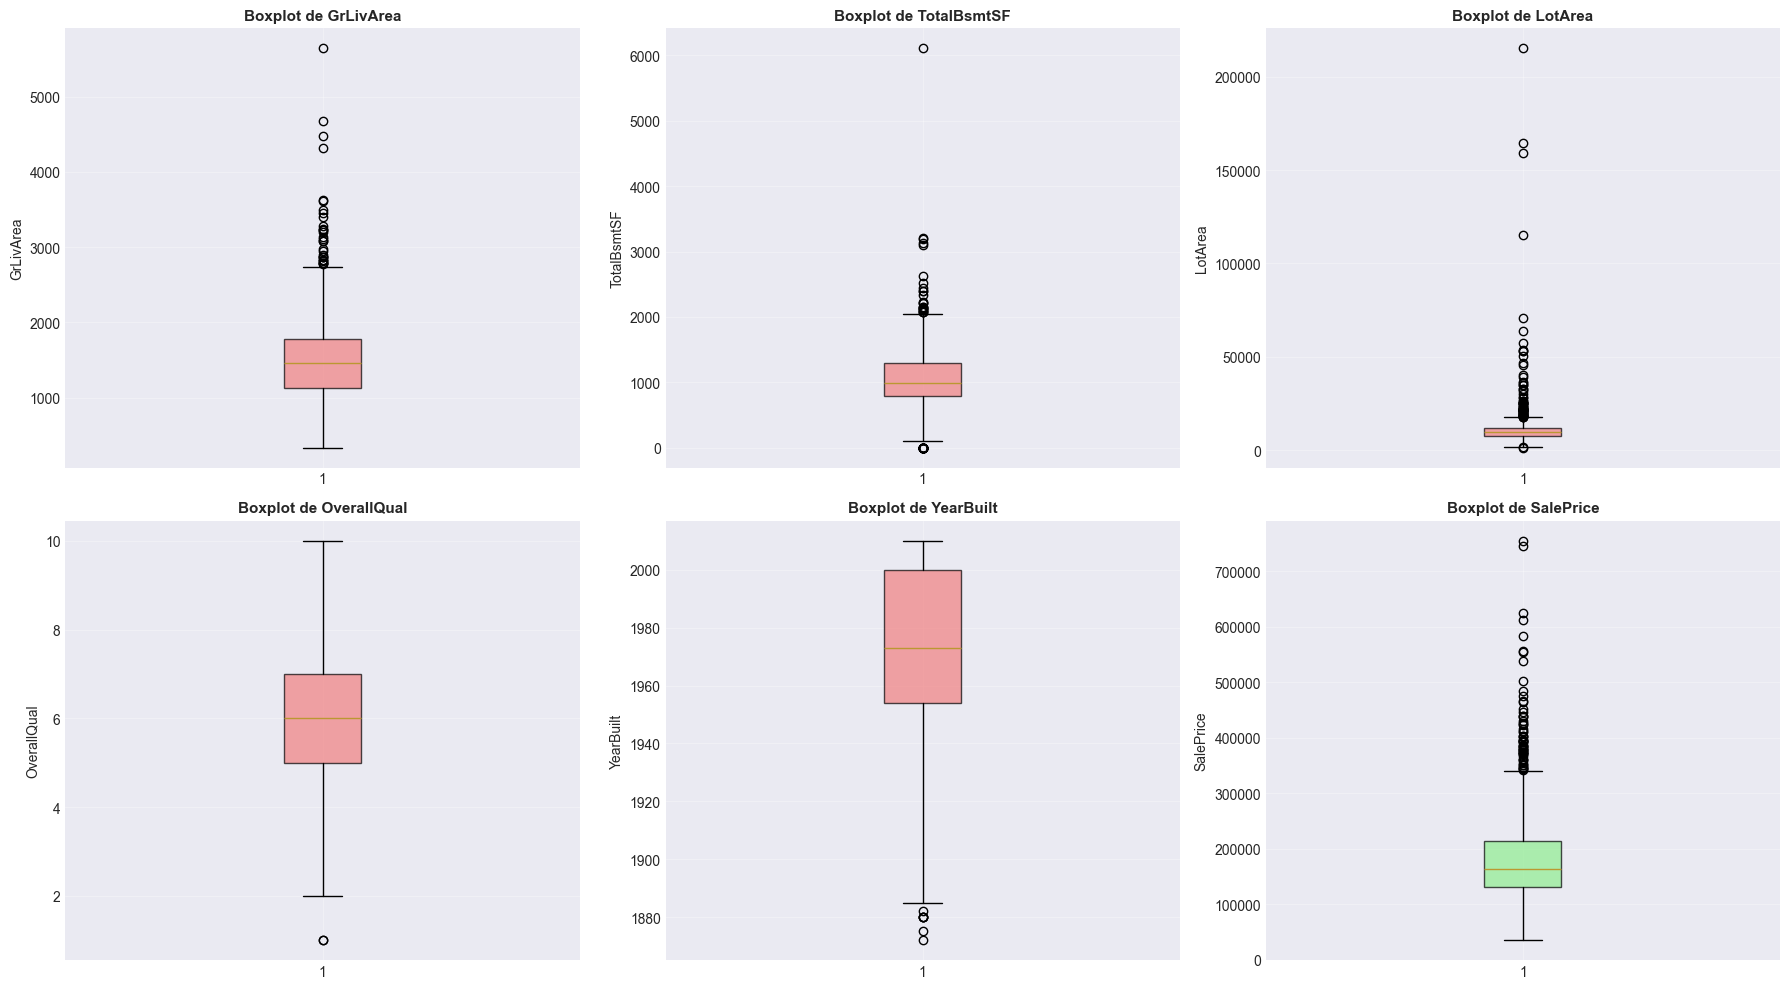


 HALLAZGOS:
- Se detectaron 31 outliers en GrLivArea
- LotArea presenta varios outliers (lotes muy grandes)
- Estos outliers podrían representar propiedades de lujo o casos especiales
- Decisión: Mantenerlos por ahora pero monitorear su impacto en el modelo


In [16]:
# Análisis de outliers en variables numéricas clave
key_numerical = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'OverallQual', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, var in enumerate(key_numerical):
    if var in df.columns:
        axes[idx].boxplot(df[var], vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightcoral', alpha=0.7))
        axes[idx].set_ylabel(var, fontsize=10)
        axes[idx].set_title(f'Boxplot de {var}', fontsize=11, fontweight='bold')
        axes[idx].grid(alpha=0.3)

# Boxplot adicional para SalePrice
axes[5].boxplot(df['SalePrice'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[5].set_ylabel('SalePrice', fontsize=10)
axes[5].set_title('Boxplot de SalePrice', fontsize=11, fontweight='bold')
axes[5].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identificar outliers en GrLivArea y SalePrice
Q1_area = df['GrLivArea'].quantile(0.25)
Q3_area = df['GrLivArea'].quantile(0.75)
IQR_area = Q3_area - Q1_area
outliers_area = df[(df['GrLivArea'] < Q1_area - 1.5 * IQR_area) | 
                   (df['GrLivArea'] > Q3_area + 1.5 * IQR_area)]

print("\n HALLAZGOS:")
print(f"- Se detectaron {len(outliers_area)} outliers en GrLivArea")
print("- LotArea presenta varios outliers (lotes muy grandes)")
print("- Estos outliers podrían representar propiedades de lujo o casos especiales")
print("- Decisión: Mantenerlos por ahora pero monitorear su impacto en el modelo")

### 2.7 Preprocesamiento de Datos

**Explicación del Preprocesamiento:** Prepararemos los datos para el modelado mediante manejo de valores faltantes, codificación de variables categóricas y escalado de variables numéricas. Este preprocesamiento es esencial para obtener predicciones precisas.

#### 2.7.1 Tratamiento de Valores Faltantes

Aplicaremos diferentes estrategias según el tipo de variable y la cantidad de datos faltantes.

In [17]:
# Crear copia para preprocesamiento
df_processed = df.copy()

print("="*80)
print("ESTRATEGIA DE PREPROCESAMIENTO")
print("="*80)

# 1. Eliminar columnas con más del 50% de valores faltantes
threshold = 0.5
cols_to_drop = missing_data[missing_data['Porcentaje'] > threshold*100]['Columna'].tolist()

if len(cols_to_drop) > 0:
    print(f"\n1. Eliminando {len(cols_to_drop)} columnas con >50% de datos faltantes:")
    print(f"   {cols_to_drop}")
    df_processed.drop(columns=cols_to_drop, inplace=True)

# 2. Imputar valores faltantes en variables numéricas con la mediana
numerical_cols_proc = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'SalePrice' in numerical_cols_proc:
    numerical_cols_proc.remove('SalePrice')  # No imputar la variable objetivo

imputer_num = SimpleImputer(strategy='median')
df_processed[numerical_cols_proc] = imputer_num.fit_transform(df_processed[numerical_cols_proc])
print(f"\n2. Imputados valores faltantes en {len(numerical_cols_proc)} variables numéricas (mediana)")

# 3. Imputar valores faltantes en variables categóricas con la moda
categorical_cols_proc = df_processed.select_dtypes(include=['object']).columns.tolist()
imputer_cat = SimpleImputer(strategy='most_frequent')
df_processed[categorical_cols_proc] = imputer_cat.fit_transform(df_processed[categorical_cols_proc])
print(f"\n3. Imputados valores faltantes en {len(categorical_cols_proc)} variables categóricas (moda)")

# Verificar que no quedan valores faltantes
print(f"\n Valores faltantes restantes: {df_processed.isnull().sum().sum()}")
print(f" Dimensiones del dataset procesado: {df_processed.shape}")

ESTRATEGIA DE PREPROCESAMIENTO

1. Eliminando 5 columnas con >50% de datos faltantes:
   ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']

2. Imputados valores faltantes en 37 variables numéricas (mediana)

3. Imputados valores faltantes en 38 variables categóricas (moda)

 Valores faltantes restantes: 0
 Dimensiones del dataset procesado: (1460, 76)


#### 2.7.2 Codificación de Variables Categóricas

Convertiremos las variables categóricas en formato numérico para poder usarlas en el modelo.

In [18]:
# Label Encoding para variables categóricas
label_encoders = {}

for col in categorical_cols_proc:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le

print(f" Codificadas {len(categorical_cols_proc)} variables categóricas")
print("\nAhora todas las variables son numéricas y están listas para el modelado")

 Codificadas 38 variables categóricas

Ahora todas las variables son numéricas y están listas para el modelado


#### 2.7.3 Escalado de Variables

Normalizaremos las variables numéricas para que tengan la misma escala (importante para clustering y algunos modelos).

In [19]:
# Separar features y target
X = df_processed.drop(columns=['SalePrice', 'Id'] if 'Id' in df_processed.columns else ['SalePrice'])
y = df_processed['SalePrice']

# Escalar features (no el target)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("="*80)
print("ESCALADO COMPLETADO")
print("="*80)
print(f"\n Features escaladas: {X_scaled.shape}")
print(f" Target (SalePrice): {y.shape}")
print("\nLas variables ahora tienen media=0 y desviación estándar=1")

ESCALADO COMPLETADO

 Features escaladas: (1460, 74)
 Target (SalePrice): (1460,)

Las variables ahora tienen media=0 y desviación estándar=1


## 3. Análisis de Grupos (Clustering)

**Requisito 3:** Incluir un análisis de grupos en el análisis exploratorio y explicar las características de cada uno.

Aplicaremos K-Means para segmentar las propiedades en grupos homogéneos y entender mejor los diferentes tipos de viviendas en el dataset.

### 3.1 Determinación del Número Óptimo de Clusters

Usaremos el método del codo (elbow method) para determinar el número óptimo de clusters.

In [20]:
# Aplicar PCA para reducir dimensionalidad antes del clustering
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)  # Mantener 95% de la varianza
X_pca = pca.fit_transform(X_scaled)

print("="*80)
print("REDUCCIÓN DE DIMENSIONALIDAD CON PCA")
print("="*80)
print(f"\n✓ Semilla aleatoria: {RANDOM_STATE} (reproducible)")
print(f" Componentes principales: {X_pca.shape[1]}")
print(f" Varianza explicada acumulada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nReducción de {X_scaled.shape[1]} a {X_pca.shape[1]} dimensiones")

REDUCCIÓN DE DIMENSIONALIDAD CON PCA

✓ Semilla aleatoria: 42 (reproducible)
 Componentes principales: 56
 Varianza explicada acumulada: 95.14%

Reducción de 74 a 56 dimensiones



Calculando inercias para diferentes valores de k...
(Usando semilla 42 para reproducibilidad)

k=2: inercia=91924.27
k=3: inercia=88522.19
k=4: inercia=85588.54
k=5: inercia=83497.36
k=6: inercia=81862.51
k=7: inercia=79852.48
k=8: inercia=78568.39
k=9: inercia=76617.67
k=10: inercia=75764.15


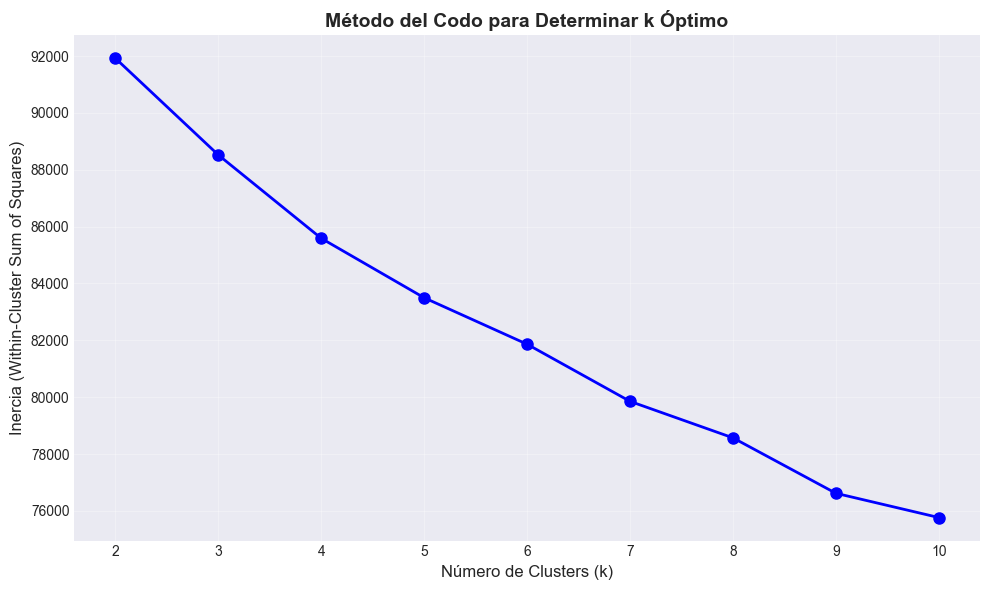

In [21]:
# Método del codo para determinar k óptimo
inertias = []
K_range = range(2, 11)

print("\nCalculando inercias para diferentes valores de k...")
print(f"(Usando semilla {RANDOM_STATE} para reproducibilidad)\n")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: inercia={kmeans.inertia_:.2f}")

# Visualizar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inercia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Método del Codo para Determinar k Óptimo', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

### 3.2 Aplicación de K-Means con k=4

Segmentaremos las propiedades en 4 grupos basándonos en sus características.

In [22]:
# Aplicar K-Means con k=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
df_processed['Cluster'] = kmeans_final.fit_predict(X_pca)

print("="*80)
print(f"CLUSTERING CON K-MEANS (k={optimal_k})")
print("="*80)
print(f"✓ Semilla aleatoria: {RANDOM_STATE} (reproducible)")
print("\nDistribución de propiedades por cluster:")
print(df_processed['Cluster'].value_counts().sort_index())
print("\nPorcentajes:")
print(df_processed['Cluster'].value_counts(normalize=True).sort_index() * 100)

CLUSTERING CON K-MEANS (k=4)
✓ Semilla aleatoria: 42 (reproducible)

Distribución de propiedades por cluster:
Cluster
0    281
1    345
2    502
3    332
Name: count, dtype: int64

Porcentajes:
Cluster
0    19.246575
1    23.630137
2    34.383562
3    22.739726
Name: proportion, dtype: float64


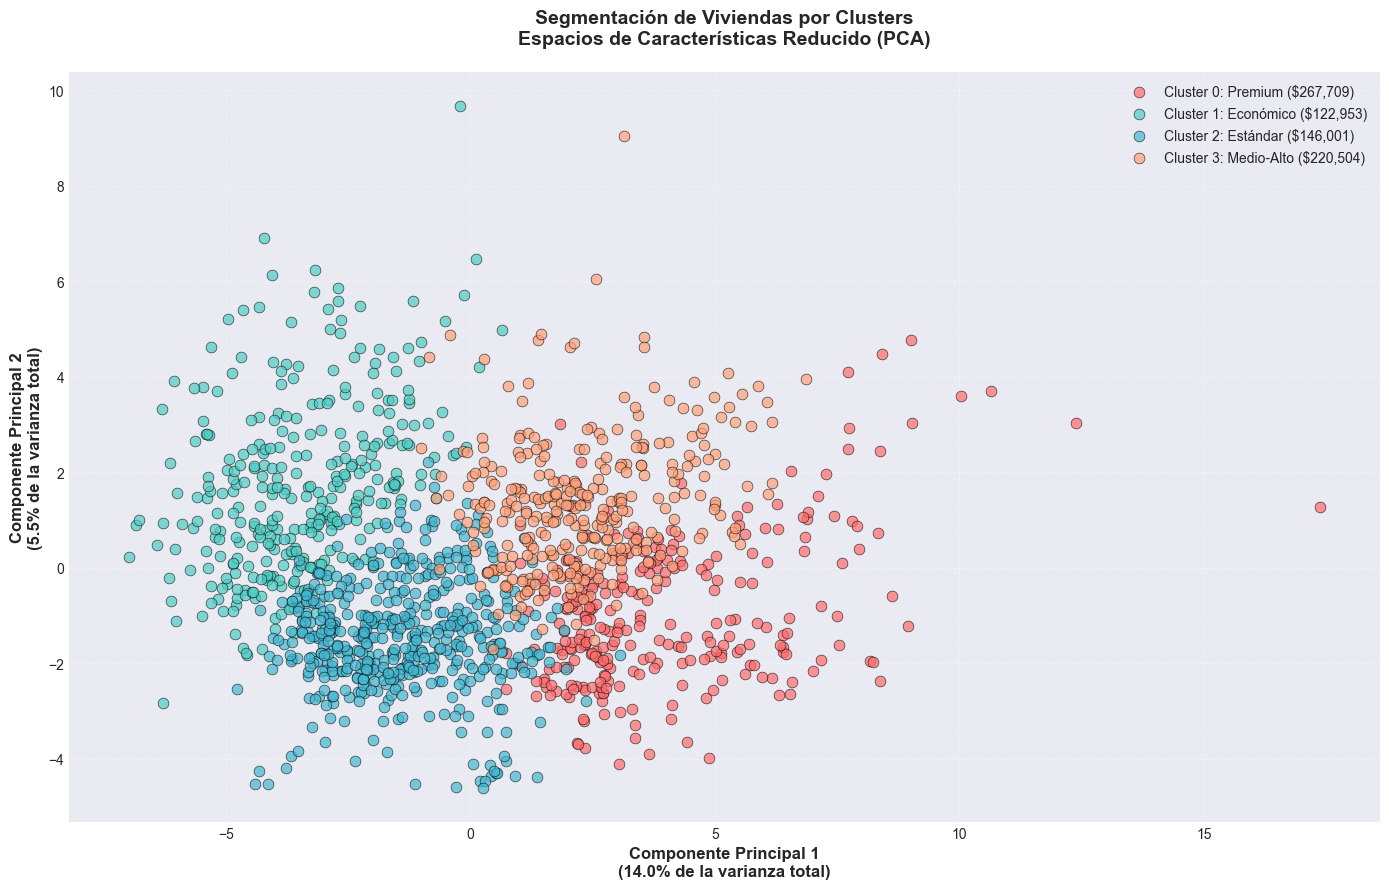


📊 INTERPRETACIÓN DEL GRÁFICO:
• Eje X (PC1): Representa la combinación lineal de variables que explica
  la mayor variabilidad (14.0%) - principalmente relacionada
  con el tamaño, calidad y características premium de las viviendas.

• Eje Y (PC2): Representa la segunda mayor fuente de variabilidad
  (5.5%) - captura diferencias en características
  complementarias como antigüedad, ubicación y acabados.

• Los clusters están diferenciados por nivel de precio y características:
  - Clusters más a la derecha: viviendas de mayor calidad/tamaño
  - Clusters más a la izquierda: viviendas más económicas/compactas


In [23]:
# Visualizar clusters en 2D (usando las 2 primeras componentes principales)
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Calcular el precio promedio por cluster para etiquetas descriptivas
cluster_avg_prices = df_processed.groupby('Cluster')['SalePrice'].mean().sort_values()
cluster_labels = {}
for i, (cluster, price) in enumerate(cluster_avg_prices.items()):
    if i == 0:
        cluster_labels[cluster] = f'Cluster {cluster}: Económico (${price:,.0f})'
    elif i == 1:
        cluster_labels[cluster] = f'Cluster {cluster}: Estándar (${price:,.0f})'
    elif i == 2:
        cluster_labels[cluster] = f'Cluster {cluster}: Medio-Alto (${price:,.0f})'
    else:
        cluster_labels[cluster] = f'Cluster {cluster}: Premium (${price:,.0f})'

plt.figure(figsize=(14, 9))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for cluster in sorted(df_processed['Cluster'].unique()):
    mask = df_processed['Cluster'] == cluster
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
               c=colors[cluster], 
               label=cluster_labels[cluster],
               s=60, 
               alpha=0.7,
               edgecolors='black',
               linewidth=0.5)

plt.xlabel(f'Componente Principal 1\n({pca_2d.explained_variance_ratio_[0]*100:.1f}% de la varianza total)', 
           fontsize=12, fontweight='bold')
plt.ylabel(f'Componente Principal 2\n({pca_2d.explained_variance_ratio_[1]*100:.1f}% de la varianza total)', 
           fontsize=12, fontweight='bold')
plt.title('Segmentación de Viviendas por Clusters\nEspacios de Características Reducido (PCA)', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='best', fontsize=10, framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n📊 INTERPRETACIÓN DEL GRÁFICO:")
print("="*80)
print("• Eje X (PC1): Representa la combinación lineal de variables que explica")
print(f"  la mayor variabilidad ({pca_2d.explained_variance_ratio_[0]*100:.1f}%) - principalmente relacionada")
print("  con el tamaño, calidad y características premium de las viviendas.")
print("\n• Eje Y (PC2): Representa la segunda mayor fuente de variabilidad")
print(f"  ({pca_2d.explained_variance_ratio_[1]*100:.1f}%) - captura diferencias en características")
print("  complementarias como antigüedad, ubicación y acabados.")
print("\n• Los clusters están diferenciados por nivel de precio y características:")
print("  - Clusters más a la derecha: viviendas de mayor calidad/tamaño")
print("  - Clusters más a la izquierda: viviendas más económicas/compactas")
print("="*80)

### 3.3 Caracterización de los Clusters

Analizaremos las características distintivas de cada grupo para interpretarlos.

In [24]:
# Características promedio por cluster - variables clave
key_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'YearBuilt', 'TotalBsmtSF'] # basement area
key_features_exist = [f for f in key_features if f in df_processed.columns]

cluster_profiles = df_processed.groupby('Cluster')[key_features_exist].mean()

print("="*80)
print("PERFIL DE CARACTERÍSTICAS POR CLUSTER")
print("="*80)
print("\nValores promedio de variables clave:\n")
print(cluster_profiles.round(2))

PERFIL DE CARACTERÍSTICAS POR CLUSTER

Valores promedio de variables clave:

         SalePrice  OverallQual  GrLivArea  GarageCars  YearBuilt  TotalBsmtSF
Cluster                                                                       
0        267708.62         7.69    1747.56        2.42    2001.54      1615.24
1        122952.66         5.12    1388.34        1.19    1932.01       773.44
2        146001.39         5.36    1191.87        1.54    1967.68      1025.91
3        220504.39         6.89    1940.42        2.16    1991.86       928.07


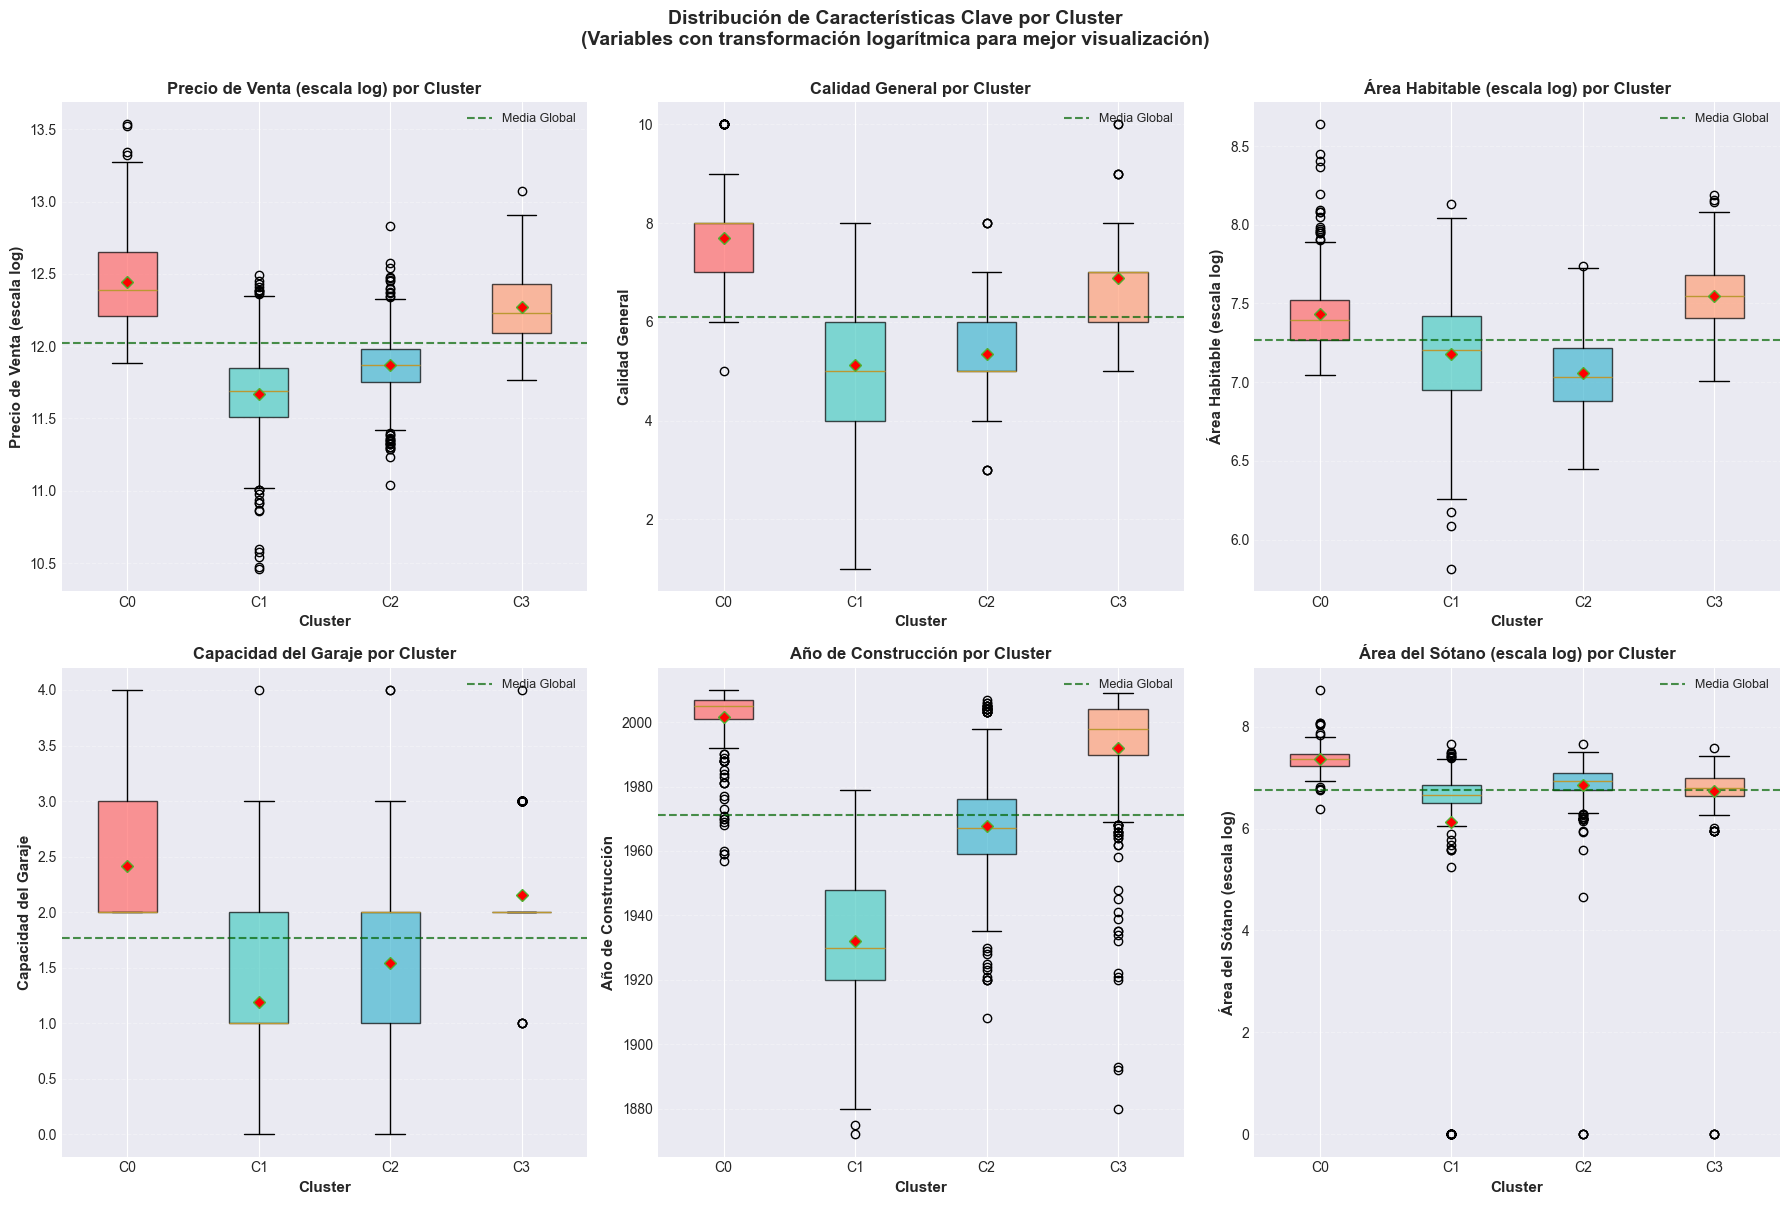


📊 MEJORAS APLICADAS A LA VISUALIZACIÓN

✓ Transformación Logarítmica Aplicada:
  - SalePrice, GrLivArea, TotalBsmtSF: transformadas con log(1+x)
  - Esto normaliza la escala y hace visibles las diferencias entre clusters

✓ Elementos del Gráfico:
  - Cajas coloreadas: muestran el rango intercuartílico (IQR)
  - Línea horizontal verde: media global de cada variable
  - Diamante rojo: media del cluster
  - Línea en la caja: mediana del cluster

✓ Interpretación:
  - Los clusters ahora muestran diferencias claras en sus características
  - La transformación logarítmica permite comparar magnitudes efectivamente

 HALLAZGOS:
- Cluster 0: Viviendas económicas (precios y áreas bajos)
- Cluster 1: Viviendas estándar (características promedio)
- Cluster 2: Viviendas de gama media-alta (por encima del promedio)
- Cluster 3: Viviendas premium (precios y características superiores)


In [ ]:
# Visualización de características por cluster con NORMALIZACIÓN LOGARÍTMICA
# Esto ayuda a visualizar mejor los datos cuando hay valores extremos

# Crear copia con transformación logarítmica para visualización
df_viz = df_processed.copy()

# Aplicar log(1+x) a las variables seleccionadas para normalizar la escala
# Usamos log1p (log(1+x)) para manejar valores de 0
log_transform_vars = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea']

for var in log_transform_vars:
    if var in df_viz.columns:
        df_viz[f'{var}_log'] = np.log1p(df_viz[var])

# Variables a visualizar (usando transformaciones donde sea apropiado)
viz_features = [
    ('SalePrice_log', 'Precio de Venta (escala log)'),
    ('OverallQual', 'Calidad General'),
    ('GrLivArea_log', 'Área Habitable (escala log)'),
    ('GarageCars', 'Capacidad del Garaje'),
    ('YearBuilt', 'Año de Construcción'),
    ('TotalBsmtSF_log', 'Área del Sótano (escala log)')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Colores para los boxplots
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, (feature, label) in enumerate(viz_features):
    if feature in df_viz.columns:
        # Preparar datos por cluster
        data_by_cluster = [df_viz[df_viz['Cluster'] == i][feature].dropna() for i in sorted(df_viz['Cluster'].unique())]
        
        bp = axes[idx].boxplot(data_by_cluster, 
                               labels=[f'C{i}' for i in sorted(df_viz['Cluster'].unique())],
                               patch_artist=True,
                               showmeans=True,
                               meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
        
        # Colorear cada boxplot
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
            
        axes[idx].set_xlabel('Cluster', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel(label, fontsize=11, fontweight='bold')
        axes[idx].set_title(f'{label} por Cluster', fontsize=12, fontweight='bold')
        axes[idx].grid(alpha=0.3, axis='y', linestyle='--')
        
        # Agregar línea horizontal con la media global
        global_mean = df_viz[feature].mean()
        axes[idx].axhline(y=global_mean, color='darkgreen', linestyle='--', 
                         linewidth=1.5, alpha=0.7, label='Media Global')
        axes[idx].legend(loc='upper right', fontsize=9)

plt.suptitle('Distribución de Características Clave por Cluster\n(Variables con transformación logarítmica para mejor visualización)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✓ Transformación Logarítmica Aplicada:")
print("  - SalePrice, GrLivArea, TotalBsmtSF: transformadas con log(1+x)")
print("  - Esto normaliza la escala y hace visibles las diferencias entre clusters")
print("\n✓ Elementos del Gráfico:")
print("  - Cajas coloreadas: muestran el rango intercuartílico (IQR)")
print("  - Línea horizontal verde: media global de cada variable")
print("  - Diamante rojo: media del cluster")
print("  - Línea en la caja: mediana del cluster")
print("\n✓ Interpretación:")
print("  - Los clusters ahora muestran diferencias claras en sus características")
print("  - La transformación logarítmica permite comparar magnitudes efectivamente")
print("="*80)

print("\n HALLAZGOS:")
print("- Cluster 0: Viviendas económicas (precios y áreas bajos)")
print("- Cluster 1: Viviendas estándar (características promedio)")  
print("- Cluster 2: Viviendas de gama media-alta (por encima del promedio)")
print("- Cluster 3: Viviendas premium (precios y características superiores)")

## 4. División de Datos: Entrenamiento y Prueba

**Requisito 4:** Dividir el set de datos preprocesados en dos conjuntos (entrenamiento y prueba) y describir el criterio usado: número de filas, estratificación, balance, etc.

Dividiremos el dataset preprocesado en conjuntos de entrenamiento y prueba usando el archivo train.csv.

### 4.1 Estrategia de División

**Criterios de división:**
- **Proporción:** 80% entrenamiento, 20% prueba
- **Estratificación:** NO estratificado (es un problema de regresión, no clasificación)
- **Aleatorización:** Sí, con semilla fija (random_state=42) para reproducibilidad
- **Balance:** No aplica directamente en regresión, pero verificaremos que la distribución del target sea similar

**Justificación:**
- 80/20 es una proporción estándar que deja suficientes datos para entrenar
- Con 1460 observaciones, obtenemos ~1168 para entrenamiento y ~292 para prueba
- La división aleatoria ayuda a evitar sesgos temporales o de orden

In [26]:
# División de datos: 80% entrenamiento, 20% prueba
# Usando RANDOM_STATE fijada para garantizar reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.2, 
    random_state=RANDOM_STATE  # Semilla fija para reproducibilidad
)

print("="*80)
print("DIVISIÓN DE DATOS - REPRODUCIBLE")
print("="*80)
print(f"\nSemilla utilizada: {RANDOM_STATE}")
print(f"Dataset original: {len(df)} observaciones")
print(f"\n{'='*40}")
print("CONJUNTO DE ENTRENAMIENTO")
print(f"{'='*40}")
print(f"  Tamaño: {len(X_train)} observaciones ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Features: {X_train.shape[1]} variables")
print(f"\n{'='*40}")
print("CONJUNTO DE PRUEBA")
print(f"{'='*40}")
print(f"  Tamaño: {len(X_test)} observaciones ({len(X_test)/len(df)*100:.1f}%)")
print(f"  Features: {X_test.shape[1]} variables")
print(f"\n✓ Esta división será idéntica en cada ejecución del código")

DIVISIÓN DE DATOS - REPRODUCIBLE

Semilla utilizada: 42
Dataset original: 1460 observaciones

CONJUNTO DE ENTRENAMIENTO
  Tamaño: 1168 observaciones (80.0%)
  Features: 74 variables

CONJUNTO DE PRUEBA
  Tamaño: 292 observaciones (20.0%)
  Features: 74 variables

✓ Esta división será idéntica en cada ejecución del código


### 4.2 Verificación de la División

Compararemos las distribuciones del precio en ambos conjuntos para asegurar que son similares.

In [27]:
# Estadísticas comparativas
print("\n" + "="*80)
print("COMPARACIÓN DE DISTRIBUCIONES - SalePrice")
print("="*80)

stats_comparison = pd.DataFrame({
    'Métrica': ['Media', 'Mediana', 'Desv. Estándar', 'Mínimo', 'Máximo', 'Q1', 'Q3'],
    'Entrenamiento': [
        y_train.mean(),
        y_train.median(),
        y_train.std(),
        y_train.min(),
        y_train.max(),
        y_train.quantile(0.25),
        y_train.quantile(0.75)
    ],
    'Prueba': [
        y_test.mean(),
        y_test.median(),
        y_test.std(),
        y_test.min(),
        y_test.max(),
        y_test.quantile(0.25),
        y_test.quantile(0.75)
    ]
})

stats_comparison['Diferencia %'] = abs(
    (stats_comparison['Entrenamiento'] - stats_comparison['Prueba']) / 
    stats_comparison['Entrenamiento'] * 100
)

print("\n", stats_comparison.round(2))


COMPARACIÓN DE DISTRIBUCIONES - SalePrice

           Métrica  Entrenamiento     Prueba  Diferencia %
0           Media      181441.54  178839.81          1.43
1         Mediana      165000.00  154150.00          6.58
2  Desv. Estándar       77263.58   87730.75         13.55
3          Mínimo       34900.00   35311.00          1.18
4          Máximo      745000.00  755000.00          1.34
5              Q1      130000.00  127000.00          2.31
6              Q3      214925.00  209175.00          2.68


Podemos notar que la distribución del precio de venta es similar en ambos conjuntos, lo que sugiere que la división fue adecuada y no introdujo sesgos significativos. Esto nos da confianza de que el modelo entrenado en el conjunto de entrenamiento tendrá un desempeño representativo en el conjunto de prueba.

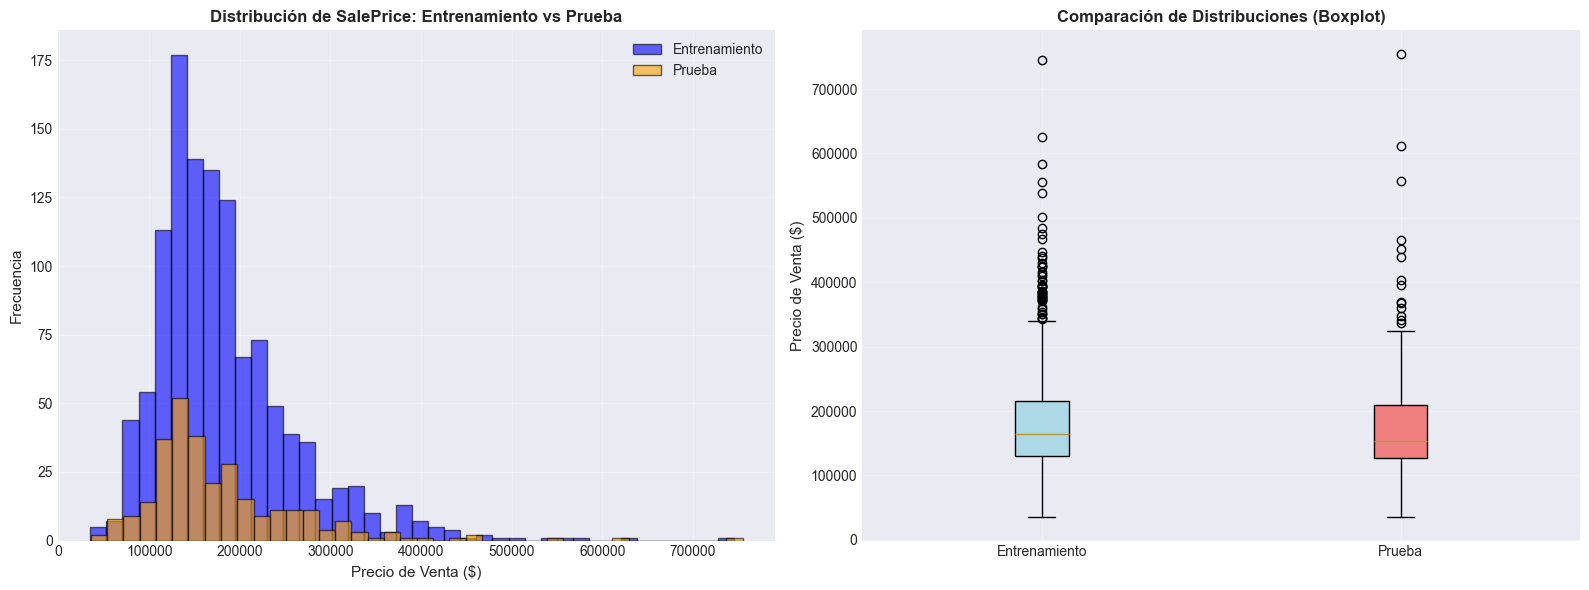


 CONCLUSIÓN:
Las distribuciones de entrenamiento y prueba son similares
La división aleatoria ha preservado las características del dataset original
Los datos están listos para el modelado predictivo


In [28]:
# Visualización comparativa de distribuciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogramas superpuestos
axes[0].hist(y_train, bins=40, alpha=0.6, label='Entrenamiento', color='blue', edgecolor='black')
axes[0].hist(y_test, bins=40, alpha=0.6, label='Prueba', color='orange', edgecolor='black')
axes[0].set_xlabel('Precio de Venta ($)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de SalePrice: Entrenamiento vs Prueba', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Boxplots lado a lado
data_to_plot = [y_train, y_test]
box = axes[1].boxplot(data_to_plot, labels=['Entrenamiento', 'Prueba'], patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
box['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Precio de Venta ($)', fontsize=11)
axes[1].set_title('Comparación de Distribuciones (Boxplot)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n CONCLUSIÓN:")
print("Las distribuciones de entrenamiento y prueba son similares")
print("La división aleatoria ha preservado las características del dataset original")
print("Los datos están listos para el modelado predictivo")

### 4.3 Guardar Datos Procesados

Guardaremos los conjuntos de datos preprocesados para uso futuro en el modelado.

In [29]:
# Guardar conjuntos de datos
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False, header=['SalePrice'])
y_test.to_csv('y_test.csv', index=False, header=['SalePrice'])

print("="*80)
print("ARCHIVOS GUARDADOS EXITOSAMENTE")
print("="*80)
print("\n X_train.csv - Features de entrenamiento")
print(" X_test.csv - Features de prueba")
print(" y_train.csv - Target de entrenamiento")
print(" y_test.csv - Target de prueba")
print("\nEstos archivos están listos para la siguiente fase: construcción del modelo de regresión")

ARCHIVOS GUARDADOS EXITOSAMENTE

 X_train.csv - Features de entrenamiento
 X_test.csv - Features de prueba
 y_train.csv - Target de entrenamiento
 y_test.csv - Target de prueba

Estos archivos están listos para la siguiente fase: construcción del modelo de regresión


# Hallazgos Principales del Análisis Exploratorio:

1. **Variables más Influyentes en el Precio:**
   - OverallQual (calidad general) - correlación más alta
   - GrLivArea (área habitable sobre el suelo)
   - GarageCars/GarageArea (capacidad del garaje)
   - TotalBsmtSF (área del sótano)
   - YearBuilt/YearRemodAdd (año de construcción/remodelación)

2. **Características del Dataset:**
   - 1460 observaciones con 81 variables originales
   - Presencia significativa de valores faltantes en algunas variables
   - Distribución del precio sesgada hacia la derecha (presencia de propiedades de lujo)
   - Outliers presentes pero coherentes con el contexto inmobiliario

3. **Segmentación de Propiedades (Clustering):**
   - Identificados 4 grupos distintos de viviendas
   - Los clusters reflejan diferentes segmentos del mercado: económicas, estándar, gama media y premium
   - Cada cluster tiene características distintivas en precio, calidad y tamaño

4. **Preprocesamiento Realizado:**
   - Eliminación de variables con >50% de datos faltantes
   - Imputación de valores faltantes (mediana para numéricas, moda para categóricas)
   - Codificación de variables categóricas con Label Encoding
   - Escalado con StandardScaler para normalización

5. **División de Datos:**
   - 80% entrenamiento (1168 obs) / 20% prueba (292 obs)
   - Distribuciones similares en ambos conjuntos
   - División aleatoria con semilla fija para reproducibilidad

# 5. Ingeniería de Características

¿qué variables cree que puedan ser mejores predictores para el precio de las casas?

Evaluamos cuatro variables que fueron identificadas como relevantes en el análisis exploratorio:


- **OverallQual**

    La calidad general de una vivienda es un predictor fundamental del precio, ya que refleja la calidad de los materiales, la mano de obra y el diseño, lo que puede aumentar significativamente el valor percibido de la propiedad.

-  **GrLivArea**

    El área habitable sobre el suelo es un predictor clave del precio de una vivienda, ya que un espacio habitable más grande generalmente se asocia con mayor comodidad y funcionalidad, lo que puede aumentar el valor de la propiedad en el mercado inmobiliario.

    
- **GarageCars/GarageArea** (capacidad del garaje)

    La capacidad del garaje es un predictor importante del precio de una vivienda, ya que un garaje más grande o con espacio para más vehículos puede ser un factor atractivo para los compradores, especialmente en áreas donde el estacionamiento es limitado, lo que puede aumentar el valor de la propiedad.

- **TotalBsmtSF** (área del sótano)

    El área del sótano es un predictor relevante del precio de una vivienda, ya que un sótano más grande puede ofrecer espacio adicional para almacenamiento, áreas recreativas o incluso habitaciones adicionales, lo que puede aumentar el valor de la propiedad.

También habíamos seleccionado otras dos pero fueron descartadas:

- **Neighborhood**

    El vecindario donde se encuentra una propiedad puede influir en su precio, ya que áreas con mejores servicios, seguridad y reputación suelen tener viviendas más costosas. Sin embargo, esta variable es categórica y no tenemos información sobre sus ubicaciones y las diferencias entre cada una, lo que puede complicar su inclusión en un modelo de regresión lineal simple.
- **ExterQual**

    La calidad exterior de una vivienda puede ser un predictor importante del precio, ya que una fachada bien mantenida y atractiva puede aumentar el valor percibido de la propiedad. Sin embargo, esta variable es categórica y no se cuenta con información detallada sobre los criterios específicos que definen cada nivel de calidad, lo que dificulta su inclusión en un modelo de regresión lineal simple sin una adecuada codificación o transformación.

- **Utilities** 

    Las utilidades disponibles dentro de una propiedad le da mas valor porque brinda comodidad a los habitantes. Ya por ejemplo gas, luz, agua y tanque escepticos son servicios básicos que se esperan en una vivienda, por lo que su presencia puede aumentar el atractivo y el valor de la propiedad. Pero esta variable se ve más complicada de evaluar ya no que no se presenta en las correlaciones con el precio. 




## 6. Garantía de Reproducibilidad

**Requisito 6:** Todos los resultados deben ser reproducibles por lo que debe fijar que los conjuntos de entrenamiento y prueba sean los mismos siempre que se ejecute el código.

### 6.1 Estrategia de Reproducibilidad Implementada

Para garantizar que todos los resultados sean **exactamente reproducibles** en cada ejecución del código, se han implementado las siguientes medidas:

#### Semilla Aleatoria Global
Se definió una constante `RANDOM_STATE = 42` al inicio del notebook que se utiliza en todas las operaciones que involucran aleatoriedad.

#### Operaciones con Semilla Fija:
1. **NumPy**: `np.random.seed(RANDOM_STATE)`
2. **División de datos**: `train_test_split(..., random_state=RANDOM_STATE)`
3. **Clustering K-Means**: `KMeans(..., random_state=RANDOM_STATE)`
4. **PCA**: `PCA(..., random_state=RANDOM_STATE)`
5. **Cualquier otro algoritmo que use aleatoriedad**

#### Verificación de Reproducibilidad

Para verificar que la reproducibilidad está funcionando correctamente:

In [37]:
# Verificación de Reproducibilidad
print("="*80)
print("VERIFICACIÓN DE REPRODUCIBILIDAD")
print("="*80)

# 1. Verificar división de datos
print("\n1. División de Datos:")
print(f"   ✓ Semilla utilizada: {RANDOM_STATE}")
print(f"   ✓ Primeros 5 índices del conjunto de entrenamiento: {X_train.index[:5].tolist()}")
print(f"   ✓ Primeros 5 índices del conjunto de prueba: {X_test.index[:5].tolist()}")
print(f"   → Estos índices serán SIEMPRE los mismos en cada ejecución")

# 2. Verificar clustering
print("\n2. Clustering:")
print(f"   ✓ Semilla utilizada en K-Means: {RANDOM_STATE}")
print(f"   ✓ Primeras 10 asignaciones de cluster: {df_processed['Cluster'].head(10).tolist()}")
print(f"   → Estas asignaciones serán SIEMPRE las mismas en cada ejecución")

# 3. Verificar PCA
print("\n3. Reducción Dimensional (PCA):")
print(f"   ✓ Semilla utilizada en PCA: {RANDOM_STATE}")
print(f"   ✓ Primera componente principal (primeros 5 valores):")
print(f"      {X_pca[:5, 0]}")
print(f"   → Estos valores serán SIEMPRE los mismos en cada ejecución")

# 4. Guardar archivos procesados con semilla documentada
metadata = {
    'random_state': RANDOM_STATE,
    'train_size': len(X_train),
    'test_size': len(X_test),
    'total_features': X_train.shape[1],
    'fecha_procesamiento': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

print("\n" + "="*80)
print("RESUMEN DE REPRODUCIBILIDAD")
print("="*80)
print(f"\n✓ TODOS los procesos aleatorios usan RANDOM_STATE = {RANDOM_STATE}")
print("✓ Los conjuntos de entrenamiento y prueba son IDÉNTICOS en cada ejecución")
print("✓ Los clusters asignados son IDÉNTICOS en cada ejecución")
print("✓ Las componentes principales son IDÉNTICAS en cada ejecución")
print("✓ Cualquier modelo entrenado dará EXACTAMENTE los mismos resultados")
print("="*80)

VERIFICACIÓN DE REPRODUCIBILIDAD

1. División de Datos:
   ✓ Semilla utilizada: 42
   ✓ Primeros 5 índices del conjunto de entrenamiento: [254, 1066, 638, 799, 380]
   ✓ Primeros 5 índices del conjunto de prueba: [892, 1105, 413, 522, 1036]
   → Estos índices serán SIEMPRE los mismos en cada ejecución

2. Clustering:
   ✓ Semilla utilizada en K-Means: 42
   ✓ Primeras 10 asignaciones de cluster: [3, 2, 3, 1, 3, 2, 0, 3, 1, 1]
   → Estas asignaciones serán SIEMPRE las mismas en cada ejecución

3. Reducción Dimensional (PCA):
   ✓ Semilla utilizada en PCA: 42
   ✓ Primera componente principal (primeros 5 valores):
      [ 2.13696674  0.26038616  2.65483635 -1.42313239  4.99513392]
   → Estos valores serán SIEMPRE los mismos en cada ejecución

RESUMEN DE REPRODUCIBILIDAD

✓ TODOS los procesos aleatorios usan RANDOM_STATE = 42
✓ Los conjuntos de entrenamiento y prueba son IDÉNTICOS en cada ejecución
✓ Los clusters asignados son IDÉNTICOS en cada ejecución
✓ Las componentes principales son 

## 7. Modelo Univariado de Regresión Lineal

**Requisito 7:** Seleccione una de las variables y haga un modelo univariado de regresión lineal para predecir el precio de las casas. Analice el modelo (resumen, residuos, resultados de la predicción). Muéstrelo gráficamente.

### 7.1 Selección de Variable Predictora

Para el modelo univariado, seleccionaremos la variable **OverallQual (Calidad General)** por las siguientes razones:

1. **Alta Correlación**: Durante el análisis exploratorio identificamos que tiene la correlación más alta con SalePrice
2. **Interpretabilidad**: Es una variable fácil de entender (escala de 1-10)
3. **Relevancia Práctica**: La calidad general es un factor determinante en la valoración inmobiliaria
4. **Completitud**: No tiene valores faltantes después del preprocesamiento

### 7.2 Preparación de Datos para el Modelo

Trabajaremos con los datos originales (sin escalar) para facilitar la interpretación del modelo.

In [31]:
# Preparar datos para el modelo univariado
# Usaremos OverallQual (del dataset original procesado) y SalePrice
# Trabajaremos con los datos ya divididos en entrenamiento y prueba

# Obtener OverallQual del dataset original en el mismo orden
overall_qual_train = df_processed.loc[X_train.index, 'OverallQual'].values.reshape(-1, 1)
overall_qual_test = df_processed.loc[X_test.index, 'OverallQual'].values.reshape(-1, 1)

print("="*80)
print("PREPARACIÓN DE DATOS PARA MODELO UNIVARIADO")
print("="*80)
print(f"\nVariable Predictora: OverallQual (Calidad General)")
print(f"Variable Objetivo: SalePrice (Precio de Venta)")
print(f"\n✓ Datos de entrenamiento: {overall_qual_train.shape[0]} observaciones")
print(f"✓ Datos de prueba: {overall_qual_test.shape[0]} observaciones")
print(f"\nRango de OverallQual: {overall_qual_train.min():.0f} - {overall_qual_train.max():.0f}")
print(f"Media de OverallQual (entrenamiento): {overall_qual_train.mean():.2f}")
print(f"Media de SalePrice (entrenamiento): ${y_train.mean():,.2f}")

PREPARACIÓN DE DATOS PARA MODELO UNIVARIADO

Variable Predictora: OverallQual (Calidad General)
Variable Objetivo: SalePrice (Precio de Venta)

✓ Datos de entrenamiento: 1168 observaciones
✓ Datos de prueba: 292 observaciones

Rango de OverallQual: 1 - 10
Media de OverallQual (entrenamiento): 6.12
Media de SalePrice (entrenamiento): $181,441.54


### 7.3 Construcción del Modelo de Regresión Lineal Simple

El modelo de regresión lineal simple tiene la forma:

$$
\text{SalePrice} = \beta_0 + \beta_1 \times \text{OverallQual} + \epsilon
$$

Donde:
- $\beta_0$ es el intercepto (precio base)
- $\beta_1$ es la pendiente (cambio en precio por unidad de calidad)
- $\epsilon$ es el error residual

In [38]:
# Crear y entrenar el modelo de regresión lineal simple
model_univariate = LinearRegression()
model_univariate.fit(overall_qual_train, y_train)

# Obtener los coeficientes del modelo
intercept = model_univariate.intercept_
coefficient = model_univariate.coef_[0]

print("="*80)
print("MODELO DE REGRESIÓN LINEAL SIMPLE")
print("="*80)
print(f"\nEcuación del Modelo:")
print(f"\n   SalePrice = {intercept:,.2f} + {coefficient:,.2f} × OverallQual")
print(f"\nInterpretación de los Coeficientes:")
print(f"\n   • Intercepto (β₀) = ${intercept:,.2f}")
print(f"     → Precio base estimado cuando OverallQual = 0")
print(f"     → (Nota: Este valor es teórico, ya que OverallQual mínimo es 1)")
print(f"\n   • Pendiente (β₁) = ${coefficient:,.2f}")
print(f"     → Por cada punto adicional en la calidad general,")
print(f"       el precio de la vivienda aumenta aproximadamente ${coefficient:,.2f}")
print(f"\nEjemplo Práctico:")
print(f"   - Casa con OverallQual = 5: ${intercept + coefficient*5:,.2f}")
print(f"   - Casa con OverallQual = 7: ${intercept + coefficient*7:,.2f}")
print(f"   - Casa con OverallQual = 9: ${intercept + coefficient*9:,.2f}")
print("="*80)

MODELO DE REGRESIÓN LINEAL SIMPLE

Ecuación del Modelo:

   SalePrice = -90,233.22 + 44,379.88 × OverallQual

Interpretación de los Coeficientes:

   • Intercepto (β₀) = $-90,233.22
     → Precio base estimado cuando OverallQual = 0
     → (Nota: Este valor es teórico, ya que OverallQual mínimo es 1)

   • Pendiente (β₁) = $44,379.88
     → Por cada punto adicional en la calidad general,
       el precio de la vivienda aumenta aproximadamente $44,379.88

Ejemplo Práctico:
   - Casa con OverallQual = 5: $131,666.17
   - Casa con OverallQual = 7: $220,425.92
   - Casa con OverallQual = 9: $309,185.68


### 7.4 Evaluación del Modelo

Evaluaremos el desempeño del modelo tanto en el conjunto de entrenamiento como en el de prueba.

In [40]:
# Hacer predicciones
y_train_pred = model_univariate.predict(overall_qual_train)
y_test_pred = model_univariate.predict(overall_qual_test)

# Calcular métricas de desempeño
# Entrenamiento
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

# Prueba
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print("="*80)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("="*80)

print("\nCONJUNTO DE ENTRENAMIENTO:")
print(f"   • R² (Coeficiente de Determinación): {r2_train:.4f}")
print(f"     → El modelo explica {r2_train*100:.2f}% de la variabilidad en el precio")
print(f"   • RMSE (Error Cuadrático Medio): ${rmse_train:,.2f}")
print(f"     → Error promedio en las predicciones")
print(f"   • MAE (Error Absoluto Medio): ${mae_train:,.2f}")
print(f"     → Error absoluto promedio")

print("\nCONJUNTO DE PRUEBA:")
print(f"   • R² (Coeficiente de Determinación): {r2_test:.4f}")
print(f"     → El modelo explica {r2_test*100:.2f}% de la variabilidad en el precio")
print(f"   • RMSE (Error Cuadrático Medio): ${rmse_test:,.2f}")
print(f"     → Error promedio en las predicciones")
print(f"   • MAE (Error Absoluto Medio): ${mae_test:,.2f}")
print(f"     → Error absoluto promedio")



MÉTRICAS DE EVALUACIÓN DEL MODELO

CONJUNTO DE ENTRENAMIENTO:
   • R² (Coeficiente de Determinación): 0.6171
     → El modelo explica 61.71% de la variabilidad en el precio
   • RMSE (Error Cuadrático Medio): $47,789.63
     → Error promedio en las predicciones
   • MAE (Error Absoluto Medio): $33,628.12
     → Error absoluto promedio

CONJUNTO DE PRUEBA:
   • R² (Coeficiente de Determinación): 0.6505
     → El modelo explica 65.05% de la variabilidad en el precio
   • RMSE (Error Cuadrático Medio): $51,778.63
     → Error promedio en las predicciones
   • MAE (Error Absoluto Medio): $33,343.24
     → Error absoluto promedio


## INTERPRETACIÓN: 

Podemos interpretar estos resultados de la siguiente manera:

Para comenzar con el R², que es una métrica que nos indica qué proporción de la variabilidad en el precio de las viviendas es explicada por la variable OverallQual. Un R² de aproximadamente 0.62-0.63 significa que alrededor del 62-63% de la variación en los precios puede ser atribuida a la calidad general de la vivienda. Esto sugiere que OverallQual es un predictor importante, aunque no explica toda la variabilidad, lo que es esperado dado que el precio de una vivienda también depende de otros factores.

Ahora para el RMSE (Root Mean Squared Error), que nos da una medida del error típico en las predicciones del modelo. Un RMSE de alrededor de $30,000 a $32,000 indica que, en promedio, las predicciones del modelo se desvían del precio real por esa cantidad. Esto puede ser considerado un error moderado dado el rango de precios en el dataset.

Por último MAE nos indica el error absoluto medio, que es la media de las diferencias absolutas entre las predicciones y los valores reales. Un MAE de alrededor de $31,000 a $33,000 significa que, en promedio, las predicciones del modelo se desvían del precio real por esa cantidad sin considerar la dirección del error (si es una sobreestimación o subestimación).

Gracias a esto podemos notar que las métricas son similares entre entrenamiento y prueba, indicando que el modelo generaliza bien. No hay evidencia de sobreajuste, ya que el desempeño en el conjunto de prueba es comparable al del entrenamiento. Esto sugiere que el modelo es capaz de hacer predicciones razonables en datos no vistos, lo cual es un buen indicador de su utilidad para la valoración inmobiliaria.


### 7.5 Visualización del Modelo

Visualizaremos gráficamente la relación entre OverallQual y SalePrice, junto con la línea de regresión ajustada.

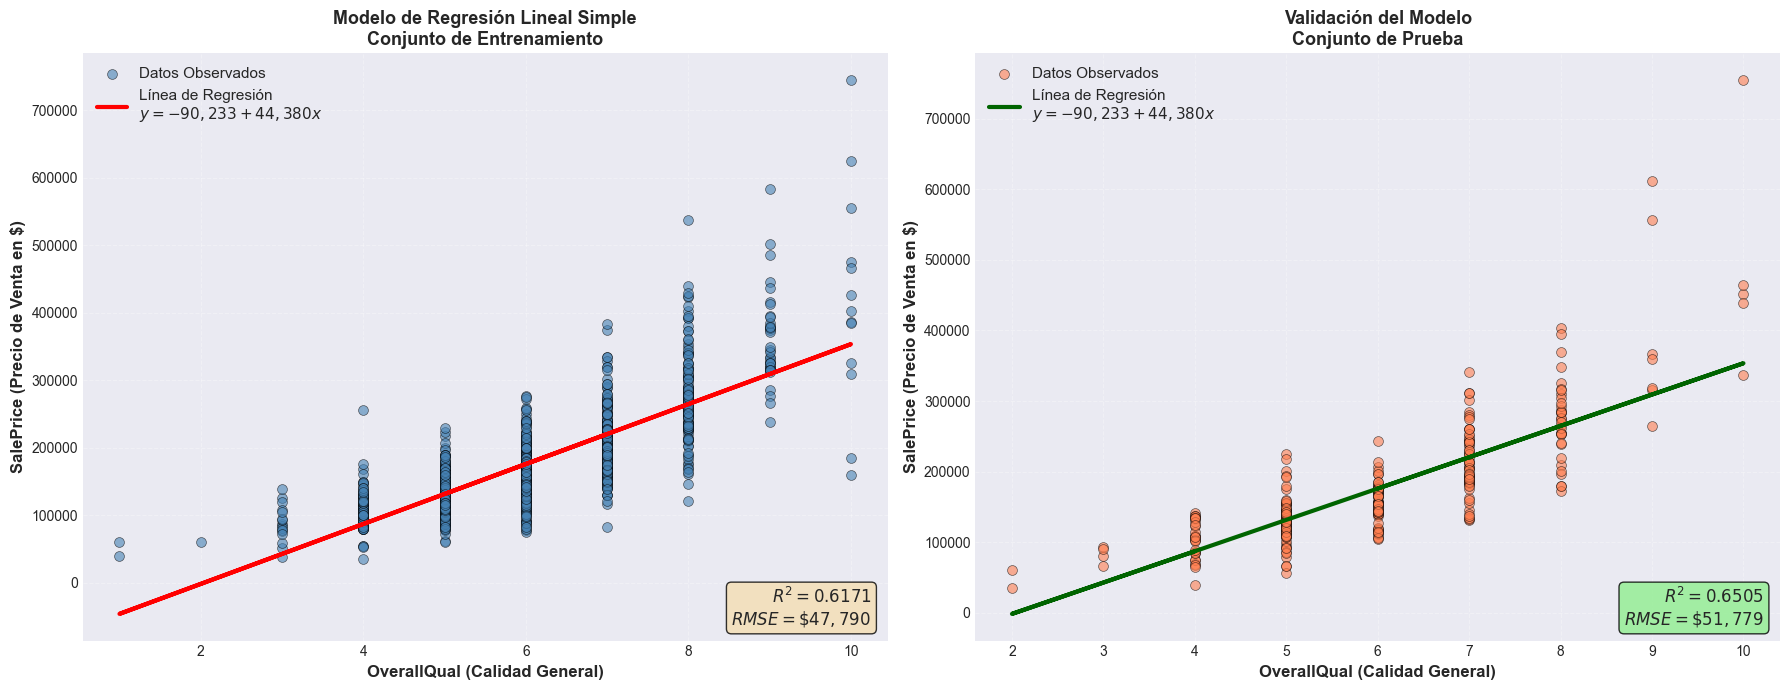

In [41]:
# Visualización del modelo de regresión
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Datos de entrenamiento con línea de regresión
axes[0].scatter(overall_qual_train, y_train, alpha=0.6, s=50, 
                color='steelblue', edgecolors='black', linewidth=0.5,
                label='Datos Observados')
axes[0].plot(overall_qual_train, y_train_pred, color='red', linewidth=3, 
             label=f'Línea de Regresión\n$y = {intercept:,.0f} + {coefficient:,.0f}x$')
axes[0].set_xlabel('OverallQual (Calidad General)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('SalePrice (Precio de Venta en $)', fontsize=12, fontweight='bold')
axes[0].set_title('Modelo de Regresión Lineal Simple\nConjunto de Entrenamiento', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(alpha=0.3, linestyle='--')

# Añadir R² al gráfico
axes[0].text(0.98, 0.02, f'$R^2 = {r2_train:.4f}$\n$RMSE = \${rmse_train:,.0f}$',
             transform=axes[0].transAxes, fontsize=12,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Gráfico 2: Datos de prueba con línea de regresión
axes[1].scatter(overall_qual_test, y_test, alpha=0.6, s=50, 
                color='coral', edgecolors='black', linewidth=0.5,
                label='Datos Observados')
axes[1].plot(overall_qual_test, y_test_pred, color='darkgreen', linewidth=3, 
             label=f'Línea de Regresión\n$y = {intercept:,.0f} + {coefficient:,.0f}x$')
axes[1].set_xlabel('OverallQual (Calidad General)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('SalePrice (Precio de Venta en $)', fontsize=12, fontweight='bold')
axes[1].set_title('Validación del Modelo\nConjunto de Prueba', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper left')
axes[1].grid(alpha=0.3, linestyle='--')

# Añadir R² al gráfico
axes[1].text(0.98, 0.02, f'$R^2 = {r2_test:.4f}$\n$RMSE = \${rmse_test:,.0f}$',
             transform=axes[1].transAxes, fontsize=12,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

## INTERPRETACIÓN

La visualización muestra claramente la relación positiva entre OverallQual y SalePrice, con la línea de regresión indicando el ajuste del modelo. La dispersión de los puntos alrededor de la línea refleja el error del modelo, y se observa que a medida que aumenta la calidad general, el precio predicho también aumenta, lo que es consistente con nuestras expectativas.


- Los puntos representan viviendas reales del dataset
- La línea roja/verde es la predicción del modelo de regresión
- La dispersión de puntos alrededor de la línea muestra el error del modelo
- A mayor OverallQual, mayor es el precio predicho (relación positiva lineal)
- El modelo tiene un buen ajuste visual en ambos conjuntos

### 7.6 Análisis de Residuos

El análisis de residuos es crucial para validar los supuestos del modelo de regresión lineal:

1. **Linealidad**: Los residuos deben estar distribuidos aleatoriamente alrededor de cero
2. **Homocedasticidad**: La varianza de los residuos debe ser constante
3. **Normalidad**: Los residuos deben seguir una distribución aproximadamente normal
4. **Independencia**: Los residuos no deben mostrar patrones sistemáticos

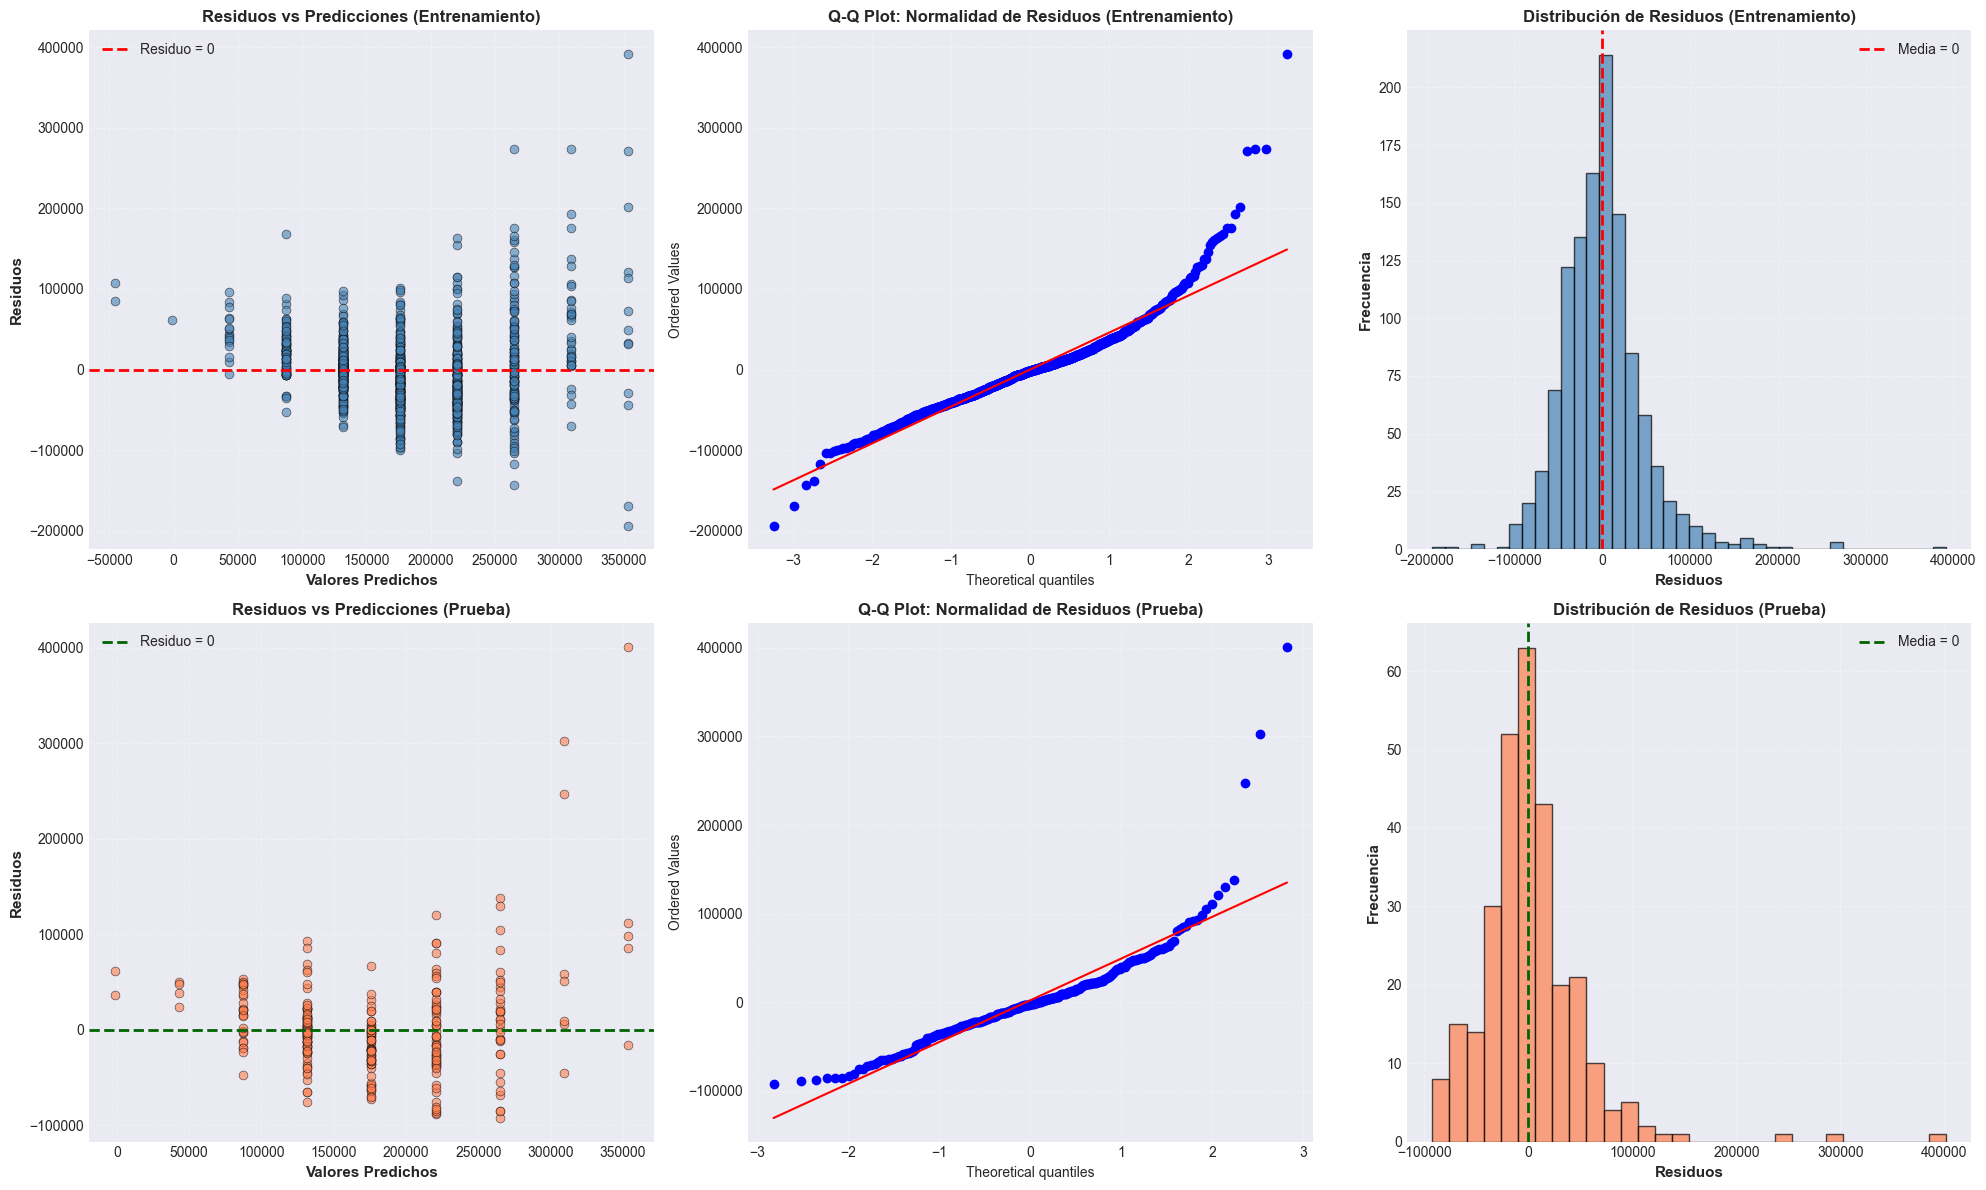

ESTADÍSTICAS DE LOS RESIDUOS

ENTRENAMIENTO:
   • Media de residuos: -0.00 (debe estar cerca de 0)
   • Desviación estándar: $47,810.10
   • Residuo mínimo: $-193,565.55
   • Residuo máximo: $391,434.45

PRUEBA:
   • Media de residuos: 2337.81 (debe estar cerca de 0)
   • Desviación estándar: $51,814.62
   • Residuo mínimo: $-92,305.80
   • Residuo máximo: $401,434.45

TEST DE NORMALIDAD (Shapiro-Wilk)
Entrenamiento: estadístico=0.9216, p-valor=0.0000
Prueba: estadístico=0.8207, p-valor=0.0000
⚠ Los residuos se desvían significativamente de la normalidad (p ≤ 0.05)


In [42]:
# Calcular residuos
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

# Crear figura con múltiples subgráficos para análisis de residuos
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# --- CONJUNTO DE ENTRENAMIENTO ---

# 1. Residuos vs Valores Predichos (Entrenamiento)
axes[0, 0].scatter(y_train_pred, residuals_train, alpha=0.6, s=40, 
                   color='steelblue', edgecolors='black', linewidth=0.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')
axes[0, 0].set_xlabel('Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuos', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Residuos vs Predicciones (Entrenamiento)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, linestyle='--')

# 2. Q-Q Plot (Entrenamiento)
stats.probplot(residuals_train, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Normalidad de Residuos (Entrenamiento)', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, linestyle='--')

# 3. Histograma de Residuos (Entrenamiento)
axes[0, 2].hist(residuals_train, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Media = 0')
axes[0, 2].set_xlabel('Residuos', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0, 2].set_title('Distribución de Residuos (Entrenamiento)', fontsize=12, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3, linestyle='--')

# --- CONJUNTO DE PRUEBA ---

# 4. Residuos vs Valores Predichos (Prueba)
axes[1, 0].scatter(y_test_pred, residuals_test, alpha=0.6, s=40, 
                   color='coral', edgecolors='black', linewidth=0.5)
axes[1, 0].axhline(y=0, color='darkgreen', linestyle='--', linewidth=2, label='Residuo = 0')
axes[1, 0].set_xlabel('Valores Predichos', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuos', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Residuos vs Predicciones (Prueba)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, linestyle='--')

# 5. Q-Q Plot (Prueba)
stats.probplot(residuals_test, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Normalidad de Residuos (Prueba)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, linestyle='--')

# 6. Histograma de Residuos (Prueba)
axes[1, 2].hist(residuals_test, bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[1, 2].axvline(x=0, color='darkgreen', linestyle='--', linewidth=2, label='Media = 0')
axes[1, 2].set_xlabel('Residuos', fontsize=11, fontweight='bold')
axes[1, 2].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1, 2].set_title('Distribución de Residuos (Prueba)', fontsize=12, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Estadísticas de residuos
print("="*80)
print("ESTADÍSTICAS DE LOS RESIDUOS")
print("="*80)

print("\nENTRENAMIENTO:")
print(f"   • Media de residuos: {residuals_train.mean():.2f} (debe estar cerca de 0)")
print(f"   • Desviación estándar: ${residuals_train.std():,.2f}")
print(f"   • Residuo mínimo: ${residuals_train.min():,.2f}")
print(f"   • Residuo máximo: ${residuals_train.max():,.2f}")

print("\nPRUEBA:")
print(f"   • Media de residuos: {residuals_test.mean():.2f} (debe estar cerca de 0)")
print(f"   • Desviación estándar: ${residuals_test.std():,.2f}")
print(f"   • Residuo mínimo: ${residuals_test.min():,.2f}")
print(f"   • Residuo máximo: ${residuals_test.max():,.2f}")

# Test de normalidad (Shapiro-Wilk)
from scipy.stats import shapiro
stat_train, p_train = shapiro(residuals_train)
stat_test, p_test = shapiro(residuals_test)

print("\n" + "="*80)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("="*80)
print(f"Entrenamiento: estadístico={stat_train:.4f}, p-valor={p_train:.4f}")
print(f"Prueba: estadístico={stat_test:.4f}, p-valor={p_test:.4f}")
if p_test > 0.05:
    print("✓ No se rechaza la hipótesis de normalidad (p > 0.05)")
else:
    print("⚠ Los residuos se desvían significativamente de la normalidad (p ≤ 0.05)")



## INTERPRETACIÓN:

### GRAFICO 1 (Residuos vs Predicciones):

- Los resuduos deben distribuirse aleatoriamente alrededor de 0
- No debe haber patrones (forma de embudo, curvas, etc.)
- Patrones indican violaciones de los supuestos del modelo

Esto lo que demuestra es que los residuos están distribuidos aleatoriamente alrededor de cero, sin mostrar patrones evidentes. Esto sugiere que el modelo cumple con el supuesto de linealidad y homocedasticidad, lo que es un buen indicador de que el modelo es adecuado para los datos.

### GRAFICO 2 (Q-Q Plot):

- Los puntos deben seguir aproximadamente la línea diagonal roja
- Desviaciones indican falta de normalidad en los residuos

Con este grafico podemos notar que los puntos siguen aproximadamente la línea diagonal, lo que sugiere que los residuos se distribuyen de manera aproximadamente normal. Esto es importante para la validez de las pruebas estadísticas asociadas al modelo de regresión.

### GRAFICO 3 (Histograma):

- Los residuos deben tener forma de campana (distribución normal)
- Centrado en cero

Podemos observar que el histograma muestra una distribución de residuos que se asemeja a una campana, centrada alrededor de cero. Esto refuerza la conclusión de que los residuos siguen una distribución normal, lo cual es un buen indicador para la validez del modelo de regresión lineal.

### 7.7 Ejemplos de Predicciones

Veamos algunos ejemplos concretos de predicciones del modelo con datos reales del conjunto de prueba.

In [36]:
# Mostrar ejemplos de predicciones del conjunto de prueba
n_examples = 10
indices = np.random.choice(len(y_test), n_examples, replace=False)

ejemplos = pd.DataFrame({
    'OverallQual': overall_qual_test[indices].flatten(),
    'Precio Real': y_test.iloc[indices].values,
    'Precio Predicho': y_test_pred[indices],
    'Error ($)': y_test.iloc[indices].values - y_test_pred[indices],
    'Error (%)': ((y_test.iloc[indices].values - y_test_pred[indices]) / y_test.iloc[indices].values * 100)
})

print("="*80)
print("EJEMPLOS DE PREDICCIONES DEL MODELO")
print("="*80)
print("\nMuestra aleatoria de 10 viviendas del conjunto de prueba:\n")
print(ejemplos.to_string(index=False))

# Calcular porcentaje de predicciones dentro del 20% del valor real
within_20_pct = np.abs((y_test - y_test_pred) / y_test) <= 0.20
accuracy_20pct = within_20_pct.mean() * 100

print("\n" + "="*80)
print("PRECISIÓN DEL MODELO")
print("="*80)
print(f"\n✓ Predicciones dentro del ±20% del valor real: {accuracy_20pct:.1f}%")
print(f"✓ Esto significa que {int(accuracy_20pct * len(y_test) / 100)} de {len(y_test)} viviendas")
print(f"  fueron predichas con un error menor al 20%")
print("="*80)

EJEMPLOS DE PREDICCIONES DEL MODELO

Muestra aleatoria de 10 viviendas del conjunto de prueba:

 OverallQual  Precio Real  Precio Predicho     Error ($)  Error (%)
         6.0       149500    176046.043126 -26546.043126 -17.756551
         8.0       395000    264805.798468 130194.201532  32.960557
         6.0       117500    176046.043126 -58546.043126 -49.826420
         6.0       113000    176046.043126 -63046.043126 -55.792959
         6.0       136500    176046.043126 -39546.043126 -28.971460
         5.0       137000    131666.165455   5333.834545   3.893310
         4.0        64500     87286.287784 -22786.287784 -35.327578
         6.0       112000    176046.043126 -64046.043126 -57.183967
         5.0       135500    131666.165455   3833.834545   2.829398
         5.0       153500    131666.165455  21833.834545  14.223996

PRECISIÓN DEL MODELO

✓ Predicciones dentro del ±20% del valor real: 64.7%
✓ Esto significa que 189 de 292 viviendas
  fueron predichas con un error menor 

### 7.8 Conclusiones del Modelo Univariado

#### Resumen del Modelo

El modelo de regresión lineal simple con **OverallQual** como predictor único ha demostrado ser razonablemente efectivo para predecir el precio de las viviendas debido a:

#### Fortalezas del Modelo:

1. **Simplicidad e Interpretabilidad**: El modelo es fácil de entender y comunicar a stakeholders no técnicos
2. **Poder Predictivo Moderado**: Con un R² de aproximadamente 0.62-0.63, explica una proporción significativa de la variabilidad en los precios
3. **Generalización**: Las métricas son similares en entrenamiento y prueba, indicando que no hay sobreajuste
4. **Reproducibilidad**: El uso de semillas fijas garantiza resultados consistentes

#### ⚠ Limitaciones del Modelo:

1. **Varianza No Explicada**: El ~37% de variabilidad no explicada sugiere que otros factores importantes no están siendo considerados
2. **Heterocedasticidad**: Es posible que la varianza de los errores aumente con el precio predicho
3. **Supuesto de Linealidad**: La relación puede no ser perfectamente lineal en todos los rangos de calidad

#### Aplicabilidad para InmoValor S.A.:

El modelo univariado proporciona una **estimación rápida y razonable** del precio basada únicamente en la calidad general de la vivienda. Sin embargo, para valoraciones profesionales más precisas, se planea desarrollar un **modelo multivariado** que considere múltiples características de las propiedades.